# Model 3: 1D Axial Dispersion Model (ADM)

This notebook implements a 1D advection-diffusion-reaction model for starch digestion and glucose absorption in the small intestine.

## Governing PDEs (Dimensionless)

$$\frac{\partial S'}{\partial \tau} = \frac{1}{Pe}\frac{\partial^2 S'}{\partial \xi^2} - \frac{\partial S'}{\partial \xi} - R(S') + \text{source}$$

$$\frac{\partial G'}{\partial \tau} = \frac{1}{Pe}\frac{\partial^2 G'}{\partial \xi^2} - \frac{\partial G'}{\partial \xi} + R(S') - \tau_{transfer} \cdot G'$$

## Boundary Conditions (Neumann)
$$\frac{\partial C}{\partial \xi}\big|_{\xi=0}=\frac{\partial C}{\partial \xi}\big|_{\xi=1}=0$$

In [174]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

In [175]:
plt.style.use('default')
plt.rcParams.update({
    'font.family': 'serif',
    'mathtext.fontset': 'stix',
    'font.size': 14,
    'axes.labelsize': 14,
    'axes.titlesize': 14,
    'legend.fontsize': 12,
    'xtick.labelsize': 12,
    'ytick.labelsize': 12,
    'axes.linewidth': 1.0,
    'xtick.direction': 'in',
    'ytick.direction': 'in',
    'xtick.major.size': 4,
    'ytick.major.size': 4,
    'xtick.major.width': 1,
    'ytick.major.width': 1,
})

## Physical Constants and Parameters

In [176]:
# -----------------------
# Physical constants
# -----------------------
kB = 1.380649e-23        # Boltzmann constant [J/K]
T  = 310.0               # Absolute temperature [K] ~ 37°C
# Molecular weights for conversion 
MW_AGU_g_per_mol = 162.141    # g/mol (anhydroglucose unit in starch)
MW_GLU_g_per_mol = 180.156    # g/mol (glucose)

In [177]:
# -----------------------
# Anatomical / flow params
# -----------------------
L   = 2.85            # small intestine length [m] CHANGED
rm  = 0.018              # radius of small intestine [m]  (1.8 cm)
d   = 2*rm               # diameter [m]
u   = 1.7e-4             # mean axial velocity [m/s]
f   = 12.0               # effective SA multiplier from folds/villi/microvilli
rho = 1000.0             # density [kg/m^3]
r0  = 0.38e-9            # radius of a glucose molecule [m] (38 Å)
M0_g = 50.0              # initial starch mass [g]
mu = 1e-3  # viscosity [Pa·s]
d_h = 2.0 * rm / 600 # Hydraulic diameter
# Molecular diffusivity of glucose
Dm_glucose = 1e-8  # [m^2/s]
# Taylor-Aris correlation for laminar pipe flow
D_ax = Dm_glucose + (u**2 * d_h**2) / (192.0 * Dm_glucose)
# Axial Peclet number: Pe = u*L / D_ax
Pe = u * L / D_ax


In [178]:
# -----------------------
# Transport correlations
# -----------------------
def diffusivity(mu: float) -> float:
    """Einstein-Stokes diffusivity [m^2/s]."""
    return kB * T / (6*np.pi*mu*r0)

def mass_transfer_k(mu: float) -> float:
    """Overall lumen mass-transfer coefficient K [m/s]."""
    D = diffusivity(mu)
    return 1.62 * ((u * D**2) / (L * d))**(1/3)

def tau_transfer(mu: float) -> float:
    """τ_transfer = (2 f K / r_m) * (L / u)."""
    K = mass_transfer_k(mu)
    return (2*f*K/rm) * (L/u)

In [179]:
# -----------------------
# Time conversions / τ-groups
# -----------------------
def tau_emptying(t_half_min: float) -> float:
    """Dimensionless emptying rate from half-time in minutes."""
    gamma = np.log(2) / (t_half_min * 60.0)  # [1/s]
    return gamma * (L / u)

def hours_to_tau(hours: float) -> float:
    return (u / L) * (hours * 3600.0)

def tau_to_hours(tau: np.ndarray) -> np.ndarray:
    return tau * (L/u) / 3600.0

def tau_R_from_Vmax(vmax_mM_per_min: float, C0_mM: float) -> float:
    """τ_R = (L/u) * (Vmax/60) / C0."""
    return (L/u) * (vmax_mM_per_min / C0_mM) / 60.0

In [180]:
# -----------------------
# Spatial discretization
# -----------------------
nx = 800
xi = np.linspace(0.0, 1.0, nx)
dxi = xi[1] - xi[0]

# Grid Peclet number (should be O(1) for stability)
print(f"Grid points: nx = {nx}")
print(f"Grid Peclet: Pe*dxi = {Pe*dxi:.2f}")

Grid points: nx = 800
Grid Peclet: Pe*dxi = 60.31


In [181]:
def second_derivative_with_neumann_both_ends(C: np.ndarray, dxi: float) -> np.ndarray:
    """
    Compute second derivative d²C/dxi² with Neumann BC at BOTH boundaries (dC/dxi = 0).
    
    Uses ghost cells: C_ext[0] = C[1] (left Neumann), C_ext[-1] = C[-2] (right Neumann).
    
    Interior points: central difference
        d²C/dxi²[i] = (C[i+1] - 2*C[i] + C[i-1]) / dxi²
    
    Left boundary (i=0): Neumann BC (dC/dxi = 0) via ghost cell C[-1] = C[1]
        d²C/dxi²[0] = (C[1] - 2*C[0] + C[-1]) / dxi²
                   = (C[1] - 2*C[0] + C[1]) / dxi²
                   = 2*(C[1] - C[0]) / dxi²
    
    Right boundary (i=n-1): Neumann BC (dC/dxi = 0) via ghost cell C[n] = C[n-2]
        d²C/dxi²[n-1] = (C[n] - 2*C[n-1] + C[n-2]) / dxi²
                     = (C[n-2] - 2*C[n-1] + C[n-2]) / dxi²
                     = 2*(C[n-2] - C[n-1]) / dxi²
    
    Returns array of same length as C.
    """
    n = len(C)
    d2C = np.zeros_like(C)
    dxi2 = dxi * dxi
    
    # Build extended array with ghost cells
    C_ext = np.empty(n + 2)
    C_ext[1:-1] = C
    C_ext[0] = C[1]      # Left Neumann: C[-1] = C[1]
    C_ext[-1] = C[-2]    # Right Neumann: C[n] = C[n-2]
    
    # Compute second derivative using extended array
    # For node i in original array, use C_ext[i+1] and neighbors C_ext[i], C_ext[i+2]
    for i in range(n):
        d2C[i] = (C_ext[i+2] - 2*C_ext[i+1] + C_ext[i]) / dxi2
    
    return d2C

## Older Model 3 : Legacy 
Improvements to make it conservative

In [182]:
def simulate_model3_old(tau_transfer_val, tau_empty_val, tau_R, KmII, tau_end,
                    xi_inject=None, Pe_override=None, bc_mode="valve",
                    rtol=1e-7, atol=1e-11):
    Pe_local = Pe if Pe_override is None else Pe_override

    xi_local = np.linspace(0.0, 1.0, nx)
    dxi_local = xi_local[1] - xi_local[0]
    # #region agent log
    try:
        import json, os, time
        log_path = '/Users/23alexanderm/Desktop/Thesis/Codes/.cursor/debug.log'
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        with open(log_path, 'a') as f:
            f.write(json.dumps({"location":"simulate_model3_old:entry","message":"Function entry","data":{"Pe_local":Pe_local,"nx":nx,"dxi_local":float(dxi_local),"rtol":rtol,"atol":atol},"hypothesisId":"H1-H3","timestamp":time.time()})+'\n')
    except: pass
    # #endregion
    xi_inject = rm/L if xi_inject is None else float(xi_inject)
    i0 = int(np.argmin(np.abs(xi_local - xi_inject)))
    i0 = np.clip(i0, 1, nx-1)
    i0_int = i0 - 1

    n = nx - 1  # Interior unknowns (nodes 1..nx-1)

    # State: [S_int(n), G_int(n), S_stomach, G_abs, S_out, G_out]
    y0 = np.zeros(2*n + 4)
    y0[2*n + 0] = 1.0  # S_stomach starts at 1

    TT, TE, TR, Km = tau_transfer_val, tau_empty_val, tau_R, KmII
    Sin, Gin = 0.0, 0.0  # Closed inlet (no upstream feed)

    def rhs(tau, y):
        S_int = y[0:n]
        G_int = y[n:2*n]
        Sst = y[2*n + 0]

        # Build full fields on nodes 0..nx-1
        S = np.empty(nx)
        G = np.empty(nx)
        S[1:] = S_int
        G[1:] = G_int
        S[0] = Sin
        G[0] = Gin

        # Advection (upwind) - uses S[0]=Sin for prescribed inflow
        dSdx = (S[1:] - S[:-1]) / dxi_local
        dGdx = (G[1:] - G[:-1]) / dxi_local

        # Dispersion: use appropriate operator based on BC mode
        # Neumann at both ends: create temporary arrays with Neumann-enforced values
        # for diffusion operator ONLY (advection uses S[0]=Sin)
        S_diff = S.copy()
        G_diff = G.copy()
        # For Neumann at inlet: enforce zero gradient for diffusion by setting
        # boundary value equal to first interior (ghost cell approach)
        # This enforces ∂C/∂ξ|_0 = 0 for dispersion while advection uses S[0]=Sin
        S_diff[0] = S[1]  # Neumann for diffusion
        G_diff[0] = G[1]  # Neumann for diffusion
        d2S = second_derivative_with_neumann_both_ends(S_diff, dxi_local)[1:]
        d2G = second_derivative_with_neumann_both_ends(G_diff, dxi_local)[1:]

        # Michaelis-Menten reaction
        R = TR * (S_int / (Km + S_int + 1e-50))

        # δ-source for starch at injection point
        srcS = np.zeros_like(S_int)
        srcS[i0_int] = (TE * Sst) / dxi_local

        # PDEs: ∂/∂τ = (1/Pe)∂²/∂ξ² - ∂/∂ξ + reactions
        dS_int = (1.0/Pe_local) * d2S - dSdx - R + srcS
        dG_int = (1.0/Pe_local) * d2G - dGdx + R - TT * G_int

        # Integral states
        lumen_G = dxi_local * np.sum(G)
        dG_abs = TT * lumen_G
        dS_out = S[-1]  # Outlet flux (purely advective, Neumann BC)
        dG_out = G[-1]
        dSst = -TE * Sst

        return np.concatenate([dS_int, dG_int, [dSst, dG_abs, dS_out, dG_out]])

    sol = solve_ivp(rhs, (0.0, tau_end), y0,
                    t_eval=tau_end*np.linspace(0.0, 1.0, 800),
                    method="BDF", rtol=rtol, atol=atol)

    # Rebuild fields for mass balance
    S_int = sol.y[0:n, :]
    G_int = sol.y[n:2*n, :]

    S = np.zeros((nx, sol.t.size))
    G = np.zeros_like(S)
    S[1:, :] = S_int
    G[1:, :] = G_int
    S[0, :] = Sin
    G[0, :] = Gin

    # Mass balance diagnostic
    Sst = sol.y[2*n + 0, :]
    Gabs = sol.y[2*n + 1, :]
    Sout = sol.y[2*n + 2, :]
    Gout = sol.y[2*n + 3, :]

    lumen_S = dxi_local * np.sum(S, axis=0)
    lumen_G = dxi_local * np.sum(G, axis=0)
    total_dimless = Sst + lumen_S + lumen_G + Gabs + Sout + Gout
    mb_err = np.max(np.abs(1.0 - total_dimless))
    # #region agent log
    try:
        import json, os, time
        log_path = '/Users/23alexanderm/Desktop/Thesis/Codes/.cursor/debug.log'
        os.makedirs(os.path.dirname(log_path), exist_ok=True)
        with open(log_path, 'a') as f:
            f.write(json.dumps({"location":"simulate_model3_old:mb_err","message":"Mass balance computed","data":{"Pe_local":Pe_local,"mb_err":float(mb_err),"total_dimless_final":float(total_dimless[-1]),"Sout_final":float(Sout[-1]),"Gout_final":float(Gout[-1])},"hypothesisId":"H1","timestamp":time.time()})+'\n')
    except: pass
    # #endregion

    t_h = tau_to_hours(sol.t)
    return dict(
        t_h=t_h,
        absorbed_fraction=Gabs,
        mb_err=mb_err,
        Pe_used=Pe_local,
        lumen_S=lumen_S,
        lumen_G=lumen_G,
        S_stomach=Sst,
    )

## Model 3: Axial Dispersion Model (ADM)

In [183]:
def second_derivative_with_right_neumann(C: np.ndarray, dxi: float) -> np.ndarray:
    """
    Compute second derivative d²C/dxi² with Neumann BC at right boundary (dC/dxi = 0).
    
    Interior points: central difference
        d²C/dxi²[i] = (C[i+1] - 2*C[i] + C[i-1]) / dxi²
    
    Right boundary (i=n-1): Neumann BC (dC/dxi = 0) implies C[n] = C[n-1]
        d²C/dxi²[n-1] = (C[n] - 2*C[n-1] + C[n-2]) / dxi²
                     = (C[n-1] - 2*C[n-1] + C[n-2]) / dxi²
                     = (C[n-2] - C[n-1]) / dxi²
    
    Left boundary (i=0): use one-sided difference
        d²C/dxi²[0] = (C[2] - 2*C[1] + C[0]) / dxi²
    
    Returns array of same length as C.
    """
    n = len(C)
    d2C = np.zeros_like(C)
    dxi2 = dxi * dxi
    
    # Left boundary (i=0): one-sided difference
    if n > 2:
        d2C[0] = (C[2] - 2*C[1] + C[0]) / dxi2
    
    # Interior points (i=1 to n-2): central difference
    if n > 2:
        d2C[1:n-1] = (C[2:n] - 2*C[1:n-1] + C[0:n-2]) / dxi2
    
    # Right boundary (i=n-1): Neumann BC (dC/dxi = 0)
    if n > 1:
        d2C[n-1] = (C[n-2] - C[n-1]) / dxi2
    
    return d2C

In [184]:
# Setup simulation parameters
tau_tr = tau_transfer(mu)
tau_em = tau_emptying(20.0)  # 20 min gastric half-time
tau_end_3h = hours_to_tau(3.0)
# Cylinder volume A*L for concentration scale
A = np.pi * rm**2
V_AL_m3 = A * L
# Michaelis constant
Km_mM = 9.0
C0_mM = (M0_g / MW_AGU_g_per_mol) / V_AL_m3
KmII = Km_mM / C0_mM

print(f"τ_transfer = {tau_tr:.2f}")
print(f"τ_emptying = {tau_em:.2f}")
print(f"Km (dimensionless) = {KmII:.4f}")

τ_transfer = 3.04
τ_emptying = 9.68
Km (dimensionless) = 0.0847


In [185]:
# Main demonstration: Absorption curves at different Vmax values
Vmax_list = [4.0, 9.0, 16]

plt.figure(figsize=(8, 5))
print(f"Simulating with Pe = {Pe:.1f}")
print("=" * 50)

for vmax, ls in zip(Vmax_list, [":", "--", "-"]):
    tauR = tau_R_from_Vmax(vmax, C0_mM)
    res = simulate_model3_old(
        tau_tr, tau_em, tauR, KmII,
        tau_end=tau_end_3h,
        xi_inject=rm/L
    )
    
    absorbed_g = M0_g * res["absorbed_fraction"]
    print(f"Vmax={vmax:>4.1f} mM/min: Absorbed={absorbed_g[-1]:.1f}g, Mass err={res['mb_err']:.2e}")
    
    plt.plot(res["t_h"], absorbed_g, lw=2, ls=ls,
             label=fr"$V_{{\max}}={vmax:g}$ mM/min")

plt.xlim(0, 3)
plt.xlabel("Time [h]")
plt.ylabel("Absorbed glucose [g]")
plt.title(f"Model 3: Glucose Absorption (Pe = {Pe:.0f})")
plt.legend(frameon=False)
plt.tight_layout()
plt.show()

Simulating with Pe = 48188.9


KeyboardInterrupt: 

<Figure size 800x500 with 0 Axes>

## This is a demonstration that at High Pe, the model approximates a PFR

## Model 3 Conservative

In [ ]:

def simulate_model3_conservative(tau_transfer_val, tau_empty_val, tau_R, KmII, tau_end,
                                  xi_inject=None, Pe_override=None, nx_override=None,
                                  rtol=1e-8, atol=1e-11):
    # Use global nx/Pe unless overridden
    nx_local = nx if nx_override is None else nx_override
    Pe_local = Pe if Pe_override is None else Pe_override
    
    xi_local = np.linspace(0.0, 1.0, nx_local)
    dxi_local = xi_local[1] - xi_local[0]
    
    # Injection point
    xi_inject_val = rm/L if xi_inject is None else float(xi_inject)
    i0 = int(np.argmin(np.abs(xi_local - xi_inject_val)))
    i0 = np.clip(i0, 1, nx_local-1)
    i0_int = i0 - 1  # Index in interior array (nodes 1..nx-1)
    
    n = nx_local - 1  # Interior unknowns (nodes 1 to nx-1)
    
    # State vector: [S_int(n), G_int(n), S_stomach, G_abs, S_out, G_out]
    y0 = np.zeros(2*n + 4)
    y0[2*n + 0] = 1.0  # S_stomach starts at 1 (dimensionless)
    
    TT, TE, TR, Km = tau_transfer_val, tau_empty_val, tau_R, KmII
    Sin, Gin = 0.0, 0.0  # Closed inlet (no upstream feed)
    
    def rhs_conservative(tau, y):
        """
        Conservative RHS using face-flux divergence.
        
        Face flux: J_{i+1/2} = C_i - (1/Pe)*(C[i+1]-C[i])/dxi  (upwind advection)
        Update: dC/dt = -(J_right - J_left)/dxi + sources
        """
        S_int = y[0:n]
        G_int = y[n:2*n]
        Sst = y[2*n + 0]
        
        # Build full fields on nodes 0..nx-1
        S = np.empty(nx_local)
        G = np.empty(nx_local)
        S[1:] = S_int
        G[1:] = G_int
        S[0] = Sin
        G[0] = Gin
        
        # ====================================================================
        # FACE FLUXES: J[i] = flux at face i+0.5 (between nodes i and i+1)
        # ====================================================================
        J_S = np.zeros(nx_local)
        J_G = np.zeros(nx_local)
        
        # Interior faces (i = 0 to nx-2)
        for i in range(nx_local - 1):
            # Upwind advective flux (flow rightward, u=1)
            J_adv_S = S[i]
            J_adv_G = G[i]
            # Dispersive flux (central difference)
            J_disp_S = (1.0 / Pe_local) * (S[i+1] - S[i]) / dxi_local
            J_disp_G = (1.0 / Pe_local) * (G[i+1] - G[i]) / dxi_local
            # Total flux
            J_S[i] = J_adv_S - J_disp_S
            J_G[i] = J_adv_G - J_disp_G
        
        # Outlet face (Neumann BC: dC/dxi = 0 => no dispersive flux)
        J_S[nx_local-1] = S[-1]
        J_G[nx_local-1] = G[-1]
        J_S_inlet = Sin  # Pure advection with prescribed inflow
        J_G_inlet = Gin  # Pure advection with prescribed inflow
        
        # ====================================================================
        # CONSERVATIVE UPDATE: dC/dt = -(J_right - J_left)/dxi + sources
        # ====================================================================
        
        # Michaelis-Menten reaction (starch -> glucose)
        R = TR * (S_int / (Km + S_int + 1e-50))
        
        # δ-source for starch injection at point i0
        srcS = np.zeros(n)
        srcS[i0_int] = (TE * Sst) / dxi_local
        
        # Flux divergence for interior nodes
        dS_int = np.zeros(n)
        dG_int = np.zeros(n)
        
        for i in range(n):
            node = i + 1  # Actual node index in full array
            
            # Left flux
            if node == 1:
                flux_left_S = J_S_inlet
                flux_left_G = J_G_inlet
            else:
                flux_left_S = J_S[node - 1]
                flux_left_G = J_G[node - 1]
            
            # Right flux
            flux_right_S = J_S[node]
            flux_right_G = J_G[node]
            
            # Conservative update
            dS_int[i] = -(flux_right_S - flux_left_S) / dxi_local - R[i] + srcS[i]
            dG_int[i] = -(flux_right_G - flux_left_G) / dxi_local + R[i] - TT * G_int[i]
        
        # ====================================================================
        # INTEGRAL STATES - MUST BE CONSISTENT
        # ====================================================================
        
        # Absorption: must equal exactly what's removed from G_int
        dG_abs = TT * dxi_local * np.sum(G_int)
        
        # Outlet fluxes (mass leaving domain per unit time)
        dS_out = J_S[nx_local - 1]
        dG_out = J_G[nx_local - 1]
        
        # Stomach emptying
        dSst = -TE * Sst
        
        return np.concatenate([dS_int, dG_int, [dSst, dG_abs, dS_out, dG_out]])
    
    # Solve ODE system
    t_eval = tau_end * np.linspace(0.0, 1.0, 800)
    sol = solve_ivp(rhs_conservative, (0.0, tau_end), y0,
                    t_eval=t_eval, method="BDF", rtol=rtol, atol=atol)
    
    # ========================================================================
    # POST-PROCESSING: Rebuild fields and compute mass balance
    # ========================================================================
    
    S_int = sol.y[0:n, :]
    G_int = sol.y[n:2*n, :]
    
    S = np.zeros((nx_local, sol.t.size))
    G = np.zeros_like(S)
    S[1:, :] = S_int
    G[1:, :] = G_int
    # Rebuild boundary values using same BC as in RHS
    S[0, :] = Sin
    G[0, :] = Gin
    
    # Extract integral states
    Sst = sol.y[2*n + 0, :]
    Gabs = sol.y[2*n + 1, :]
    Sout = sol.y[2*n + 2, :]
    Gout = sol.y[2*n + 3, :]
    
    # ========================================================================
    # MASS BALANCE DIAGNOSTIC
    # ========================================================================
    
    # Lumen integrals (consistent with what ODE tracks)
    lumen_S = dxi_local * np.sum(S_int, axis=0)
    lumen_G = dxi_local * np.sum(G_int, axis=0)
    
    # Total mass (should = 1 at all times)
    total_dimless = Sst + lumen_S + lumen_G + Gabs + Sout + Gout
    
    # Time-series mass error
    err_t = 1.0 - total_dimless
    max_err = np.max(np.abs(err_t))
    
    t_h = tau_to_hours(sol.t)
    
    return dict(
        t_h=t_h,
        tau=sol.t,
        absorbed_fraction=Gabs,
        err_t=err_t,
        max_err=max_err,
        mb_err=max_err,  # Alias for compatibility
        Pe_used=Pe_local,
        lumen_S=lumen_S,
        lumen_G=lumen_G,
        S_stomach=Sst,
        S_out=Sout,
        G_out=Gout,
        S_field=S,
        G_field=G,
        xi=xi_local,
        dxi=dxi_local,
    )

print("Conservative simulation function defined: simulate_model3_conservative()")

Conservative simulation function defined: simulate_model3_conservative()


## Verification Tests

The following tests verify the conservative implementation:

**Test 1**: Pe sweep with absorption (Pe = [2, 20, 200, 2000])

In [ ]:
# -----------------------
# Viscosity sweep (Pa·s): 1e-3 to 1e1 in decades
# -----------------------
mu_list = np.array([1e-3, 1e-2, 1e-1, 1e0, 1e1], dtype=float)

# Einstein–Stokes molecular diffusivity for each viscosity
D_list = kB * T / (6.0 * np.pi * mu_list * r0)

# Taylor–Aris axial dispersion for each viscosity
# D_ax = D + u^2 d_h^2 / (192 D)
Dax_list = D_list + (u**2 * d_h**2) / (192.0 * D_list)

# Peclet numbers
Pe_molecular = u * L / D_list      # if you ignore Taylor–Aris (use D only)
Pe_taylor    = u * L / Dax_list    # using Taylor–Aris axial dispersion

# Convenience: a "Pe_list" you can use downstream (Taylor–Aris version)
Pe_list = Pe_taylor.copy()
# -----------------------
# Print table
# -----------------------
print(f"Hydraulic diameter d_h = {d_h:.6g} m")
print()
print(f"{'mu [Pa·s]':>10} | {'D [m^2/s]':>12} | {'D_ax [m^2/s]':>14} | {'Pe (uL/D)':>11} | {'Pe (uL/D_ax)':>14}")
print("-"*74)
for mu, D, Dax, PeD, PeTA in zip(mu_list, D_list, Dax_list, Pe_molecular, Pe_taylor):
    print(f"{mu:10.1e} | {D:12.3e} | {Dax:14.3e} | {PeD:11.3e} | {PeTA:14.3e}")

print("\nPe_list (Taylor–Aris) =", Pe_list)


Hydraulic diameter d_h = 6e-05 m

 mu [Pa·s] |    D [m^2/s] |   D_ax [m^2/s] |   Pe (uL/D) |   Pe (uL/D_ax)
--------------------------------------------------------------------------
   1.0e-03 |    5.975e-10 |      1.504e-09 |   8.108e+05 |      3.221e+05
   1.0e-02 |    5.975e-11 |      9.128e-09 |   8.108e+06 |      5.308e+04
   1.0e-01 |    5.975e-12 |      9.069e-08 |   8.108e+07 |      5.342e+03
   1.0e+00 |    5.975e-13 |      9.069e-07 |   8.108e+08 |      5.343e+02
   1.0e+01 |    5.975e-14 |      9.069e-06 |   8.108e+09 |      5.343e+01

Pe_list (Taylor–Aris) = [3.22057906e+05 5.30765555e+04 5.34227584e+03 5.34262433e+02
 5.34262781e+01]


Viscosity Sweep: Mass Conservation (Conservative Solver)
Vmax = 9.0 mM/min, alpha = 1.0, t_half = 20.0 min

mu (Pa.s)    Pe         tau_transfer     max|err|    
-------------------------------------------------------
1e-03        1.5        3.0399           5.70e-13    
1e-02        0.1        0.6549           6.06e-14    
1e-01        0.0        0.1411           2.07e-11    
1e+00        0.0        0.0304           1.30e-13    
1e+01        0.0        0.0065           1.68e-14    


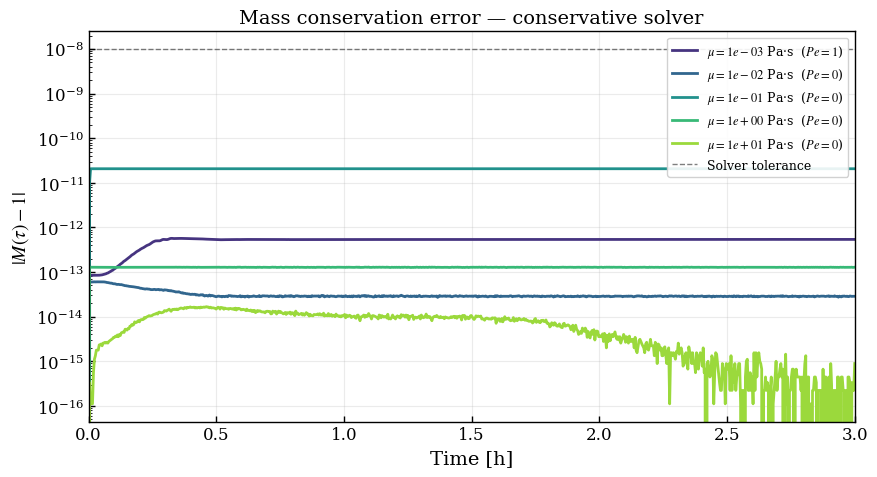

In [186]:
def test_viscosity_sweep_mass_conservation(
        mu_list=[1e-3, 1e-2, 1e-1, 1.0, 10.0],
        alpha=1.0,
        Vmax=9.0,
        t_half_min=20.0):
    """
    Viscosity sweep: plot mass conservation error over time
    for the conservative solver across physiologically relevant viscosities.
    """
    print("=" * 60)
    print("Viscosity Sweep: Mass Conservation (Conservative Solver)")
    print("=" * 60)
    print(f"Vmax = {Vmax} mM/min, alpha = {alpha}, t_half = {t_half_min} min")
    print()

    tau_end  = hours_to_tau(3.0)
    g        = np.log(2) / (t_half_min * 60.0)
    tau_em   = g * (L / u)
    tauR     = tau_R_from_Vmax(Vmax, C0_mM)

    print(f"{'mu (Pa.s)':<12} {'Pe':<10} {'tau_transfer':<16} {'max|err|':<12}")
    print("-" * 55)

    results = {}
    for mu_val in mu_list:
        Da_val, Pe_val = transfer_and_pe_from_mu(mu_val, alpha=alpha)

        res = simulate_model3_conservative(
            Da_val, tau_em, tauR, KmII, tau_end,
            Pe_override=Pe_val,
            rtol=1e-8, atol=1e-11
        )
        results[mu_val] = res

        print(f"{mu_val:<12.0e} {Pe_val:<10.1f} {Da_val:<16.4f} {res['max_err']:<12.2e}")

    # ------------------------------------------------------------------
    # Plot: mass conservation error over time for each viscosity
    # ------------------------------------------------------------------
    fig, ax = plt.subplots(figsize=(9, 5))

    colors = plt.cm.viridis(np.linspace(0.15, 0.85, len(mu_list)))

    for mu_val, color in zip(mu_list, colors):
        res = results[mu_val]
        _, Pe_val = transfer_and_pe_from_mu(mu_val, alpha=alpha)
        ax.plot(res['t_h'], np.abs(res['err_t']),
                color=color, lw=2.0,
                label=rf'$\mu = {mu_val:.0e}$ Pa·s  ($Pe = {Pe_val:.0f}$)')

    ax.axhline(1e-8, color='black', ls='--', lw=1.0, alpha=0.5,
               label='Solver tolerance')

    ax.set_yscale('log')
    ax.set_xlabel('Time [h]')
    ax.set_ylabel(r'$|M(\tau) - 1|$')
    ax.set_title('Mass conservation error — conservative solver')
    ax.set_xlim(0, 3)
    ax.legend(fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.25)

    plt.tight_layout()
    plt.savefig('mass_conservation_viscosity_sweep.png', dpi=150)
    plt.show()

    return results


results_visc = test_viscosity_sweep_mass_conservation()

In [ ]:
def transfer_and_pe_from_mu(mu: float, alpha: float = 30.0) -> tuple[float, float]:
    """
    Map viscosity μ to (wall_strength_Da, Pe_L).
    Viscosity affects both: (1) wall absorption via tau_transfer/Da, (2) Peclet via diffusivity.
    alpha: hydraulic diameter scale factor, d_h_eff = 2*rm/alpha.
    """
    Da_val = tau_transfer(mu)
    D = diffusivity(mu)
    d_h_eff = 2.0 * rm / max(alpha, 1.0)
    D_ax = D + (u**2 * d_h_eff**2) / (192.0 * D)
    Pe_val = u * L / D_ax
    return (Da_val, Pe_val)

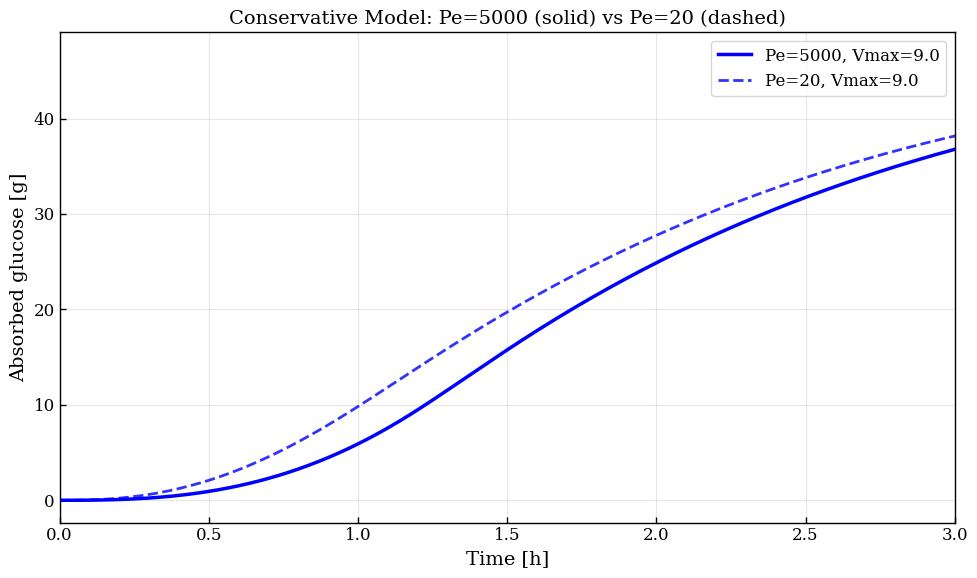

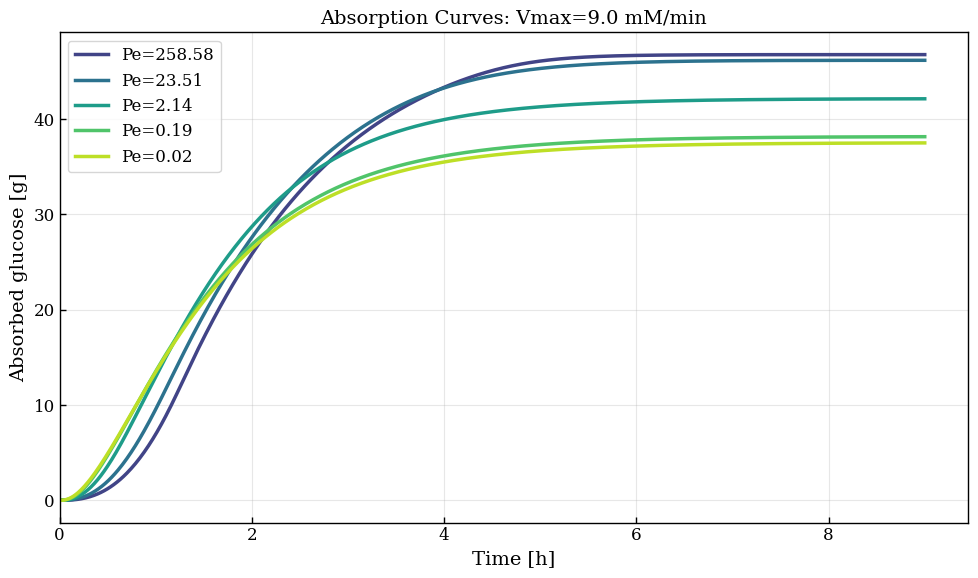

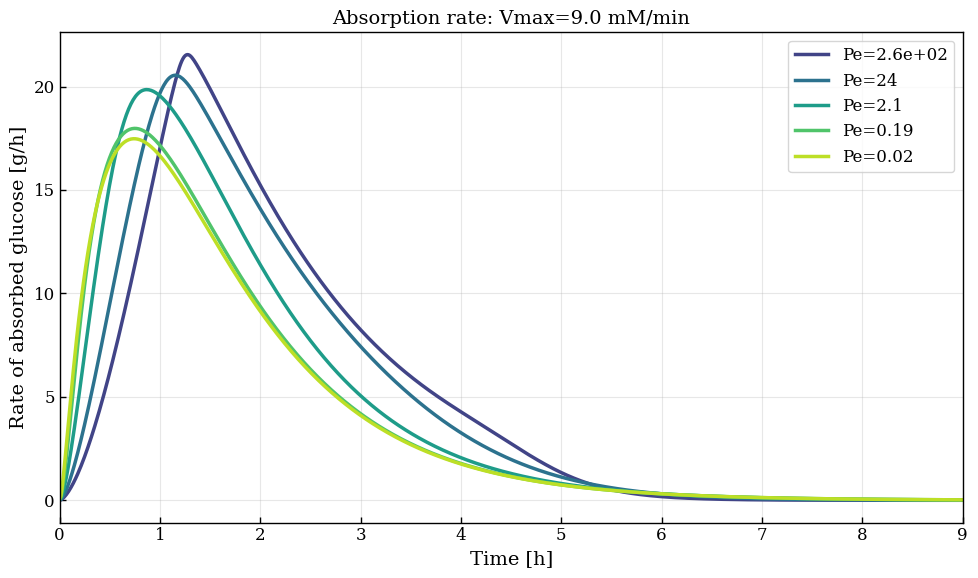

In [ ]:
def plot_vmax_pe_comparison():
    """
    Create plots comparing different Vmax values at different Pe values.
    
    Plot 1: Conservative model with Pe=5000 (solid) and Pe=20 (dashed)
            for Vmax = 4 (blue), 9 (orange), 16 (green)
    
    Plots 2-4: Three separate absorption curve plots (Pe sweep)
               for Vmax = 4, 9, 16 respectively
    Plots 2-4: Three separate absorption curve plots (Pe sweep)
               for Vmax = 4, 9, 16 respectively
    """
    tau_end = hours_to_tau(9.0)
    
    # Vmax values
    Vmax_list = [9.0] # NORMALLY FULL LIST 4-9-16
    colors_vmax = ['blue', 'orange', 'green']
    
    # Pe values for first plot
    # Viscosity sweep (μ-driven): viscosity affects both absorption (Da) and Peclet
    # Similar to figure 4c: μ → (Da, Pe) via transfer_and_pe_from_mu
    alpha_fixed = 30.0
    mu_vals = np.logspace(-3, 1, 8)  # μ from 1e-3 to 10 Pa·s

    Pe_sweep = [2.5858e2, 2.351e1, 2.14e0, 1.9e-1, 2e-2]
    
    # # =============================================================================
    # # Plot 1: Pe=5000 (solid) and Pe=20 (dashed) for all Vmax values
    # # =============================================================================
    fig1, ax1 = plt.subplots(1, 1, figsize=(10, 6))
    
    for Vmax_val, color in zip(Vmax_list, colors_vmax):
        tauR = tau_R_from_Vmax(Vmax_val, C0_mM)
        
        # Pe = 5000 (solid lines)
        res_5000 = simulate_model3_conservative(
            tau_tr, tau_em, tauR, KmII, tau_end,
            Pe_override=5000, rtol=1e-8, atol=1e-11
        )
        ax1.plot(res_5000['t_h'], M0_g * res_5000['absorbed_fraction'], '-', 
                 color=color, lw=2.5, label=f'Pe=5000, Vmax={Vmax_val}')
        
        # Pe = 20 (dashed lines)
        res_20 = simulate_model3_conservative(
            tau_tr, tau_em, tauR, KmII, tau_end,
            Pe_override=20, rtol=1e-8, atol=1e-11
        )
        ax1.plot(res_20['t_h'], M0_g * res_20['absorbed_fraction'], '--', 
                 color=color, lw=2, alpha=0.8, label=f'Pe=20, Vmax={Vmax_val}')
    
    ax1.set_xlabel('Time [h]')
    ax1.set_ylabel('Absorbed glucose [g]')
    ax1.set_title('Conservative Model: Pe=5000 (solid) vs Pe=20 (dashed)')
    ax1.legend()
    ax1.set_xlim(0, 3)
    ax1.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    # =============================================================================
    # Plots 2-4: Pe sweep for each Vmax value
    # =============================================================================
    for Vmax_val in Vmax_list:
        tauR = tau_R_from_Vmax(Vmax_val, C0_mM)
        
        # Run simulations for all Pe values
        results_vmax = {}
        for Pe_val in Pe_sweep:
            res = simulate_model3_conservative(
                tau_tr, tau_em, tauR, KmII, tau_end,
                Pe_override=Pe_val, rtol=1e-8, atol=1e-11
            )
            results_vmax[Pe_val] = res
        
        # Create plot
        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        plot_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(Pe_sweep)))
        
        for Pe_val, color in zip(Pe_sweep, plot_colors):
            res = results_vmax[Pe_val]
            Pe_label = f'Pe={Pe_val:.2f}'
            ax.plot(res['t_h'], M0_g * res['absorbed_fraction'], '-', 
                     color=color, lw=2.5, label=Pe_label)
        
        ax.set_xlabel('Time [h]')
        ax.set_ylabel('Absorbed glucose [g]')
        ax.set_title(f'Absorption Curves: Vmax={Vmax_val} mM/min')
        ax.legend()
        ax.set_xlim(0, )
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()
    
    return None

# Run the plotting function
plot_vmax_pe_comparison()

def plot_absorption_rate_vmax_pe():
    """
    Plot rate of absorbed glucose [g/h] vs time for Vmax sweep and Pe sweep.
    Rate = d/dt (M0_g * absorbed_fraction), computed via np.gradient.
    The model does not return absorption rate directly; it is derived from absorbed_fraction.
    """
    tau_end = hours_to_tau(9.0)
    Vmax_list = [9.0]
    Pe_sweep = [2.5858e2, 2.351e1, 2.14e0, 1.9e-1, 2e-2]

    for Vmax_val in Vmax_list:
        tauR = tau_R_from_Vmax(Vmax_val, C0_mM)

        results_vmax = {}
        for Pe_val in Pe_sweep:
            res = simulate_model3_conservative(
                tau_tr, tau_em, tauR, KmII, tau_end,
                Pe_override=Pe_val, rtol=1e-8, atol=1e-11
            )
            results_vmax[Pe_val] = res

        fig, ax = plt.subplots(1, 1, figsize=(10, 6))
        plot_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(Pe_sweep)))

        for Pe_val, color in zip(Pe_sweep, plot_colors):
            res = results_vmax[Pe_val]
            t_h = res["t_h"]
            absorbed_g = M0_g * res["absorbed_fraction"]
            rate_g_per_h = M0_g * np.gradient(res["absorbed_fraction"], t_h)

            ax.plot(t_h, rate_g_per_h, "-", color=color, lw=2.5, label=f"Pe={Pe_val:.2g}")

        ax.set_xlabel("Time [h]")
        ax.set_ylabel("Rate of absorbed glucose [g/h]")
        ax.set_title(f"Absorption rate: Vmax={Vmax_val} mM/min")
        ax.legend()
        ax.set_xlim(0, 9)
        ax.grid(True, alpha=0.3)
        plt.tight_layout()
        plt.show()

    return None

plot_absorption_rate_vmax_pe()

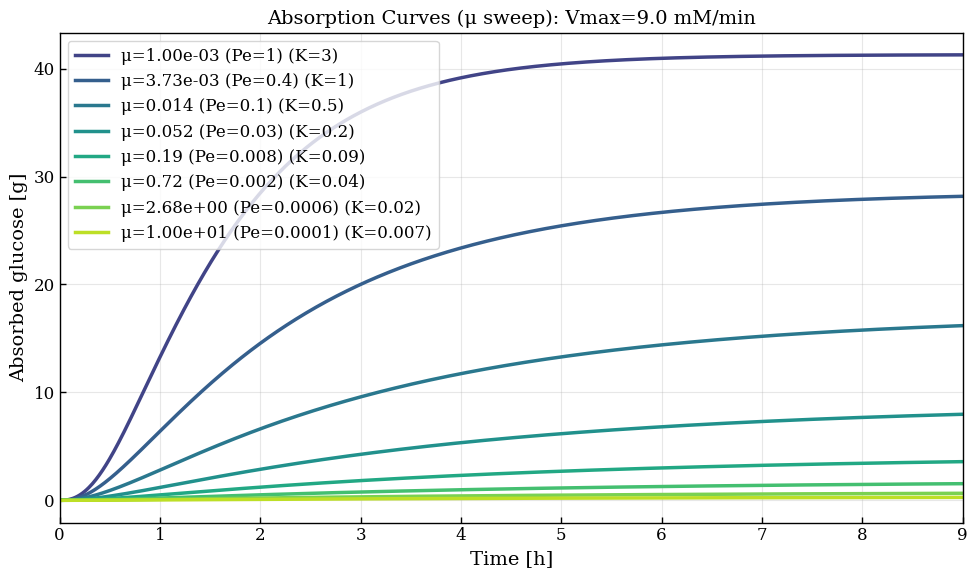

In [ ]:
# Viscosity-driven μ sweep (similar to figure 4c): viscosity affects both absorption (Da) and Peclet
tau_end = hours_to_tau(9.0)
Vmax_list = [9.0]  # NORMALLY FULL LIST [4.0, 9.0, 16.0]
alpha_fixed = 1
mu_vals = np.logspace(-3, 1, 8)  # μ from 1e-3 to 10 Pa·s

for Vmax_val in Vmax_list:
    tauR = tau_R_from_Vmax(Vmax_val, C0_mM)

    # Run simulations for all μ values (Da and Pe from viscosity)
    results_vmax = {}
    for mu_val in mu_vals:
        Da_val, Pe_val = transfer_and_pe_from_mu(mu_val, alpha_fixed)
        res = simulate_model3_conservative(
            Da_val, tau_em, tauR, KmII, tau_end,
            Pe_override=Pe_val, rtol=1e-8, atol=1e-11
        )
        results_vmax[mu_val] = (res, Pe_val, Da_val)

    # Create plot
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    plot_colors = plt.cm.viridis(np.linspace(0.2, 0.9, len(mu_vals)))

    for mu_val, color in zip(mu_vals, plot_colors):
        res, Pe_val, Da_val = results_vmax[mu_val]
        mu_label = f'μ={mu_val:.2e}' if mu_val < 0.01 or mu_val > 1 else f'μ={mu_val:.2g}'
        ax.plot(res['t_h'], M0_g * res['absorbed_fraction'], '-',
                 color=color, lw=2.5, label=f'{mu_label} (Pe={Pe_val:.1g}) (K={Da_val:.1g})')

    ax.set_xlabel('Time [h]')
    ax.set_ylabel('Absorbed glucose [g]')
    ax.set_title(f'Absorption Curves (μ sweep): Vmax={Vmax_val} mM/min')
    ax.legend()
    ax.set_xlim(0, 9)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    

    

Small test: alpha=30, 8 mu points


test: 100%|██████████| 8/8 [00:00<00:00, 210.73it/s]


  Da range: 0.006549 .. 3.04
  Pe range: 0.13 .. 1.3e+03
  Gabs at mu=1e-3: 0.7426, at mu=10: 0.002726
  Trend (should decrease with mu): 0.7426 -> 0.002726



alpha:  50%|█████     | 1/2 [00:48<00:48, 48.84s/it]

alpha=1: Da [0.006549, 3.04], Pe [0.00015, 1.5], Gabs_3h at mu=1e-3: 0.7212, at mu=10: 0.002695


alpha: 100%|██████████| 2/2 [02:15<00:00, 67.87s/it]

alpha=600: Da [0.006549, 3.04], Pe [53, 3.2e+05], Gabs_3h at mu=1e-3: 0.738, at mu=10: 0.003146


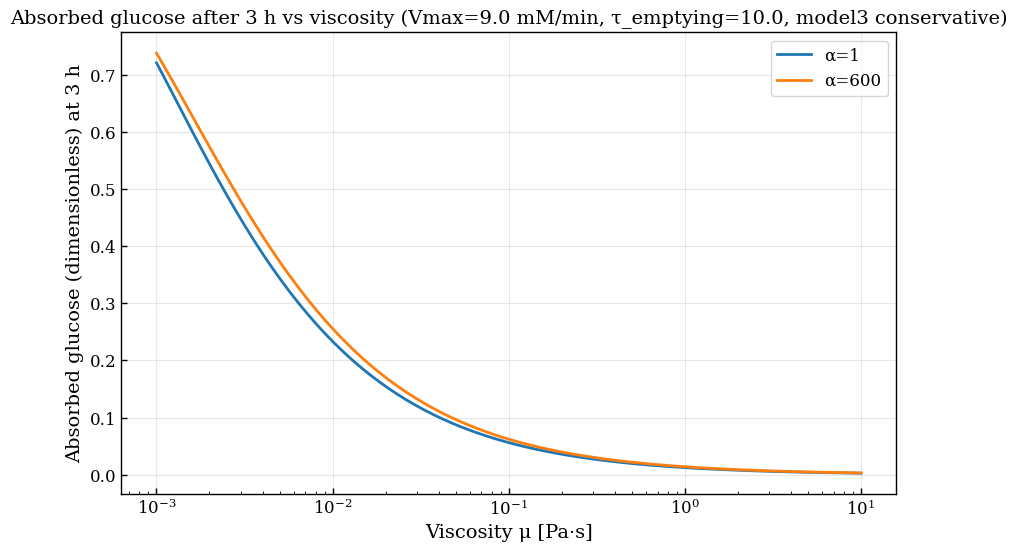

Saved Results/moxon_mu_sweep_alpha_overlay.png and Results/moxon_mu_sweep_data.npz


In [ ]:
# =============================================================================
# Moxon-style viscosity sweep: absorbed glucose after 3 h vs μ, for alpha ∈ {1, 3, 20, 60, 300}
# =============================================================================
from joblib import Parallel, delayed
from tqdm import tqdm
import os

tau_emptying = 10.0
Vmax_baseline = 9.0
nx = 400
rtol, atol = 1e-6, 1e-9
tau_end_cap = 10.0


def run_mu_point(mu, alpha, tau_emptying_val, Vmax_baseline=9.0, nx=400, rtol=1e-6, atol=1e-9):
    """Run one (mu, alpha) point, return absorbed at 3h plus debug info."""
    tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)
    wall_strength_Da, Pe_val = transfer_and_pe_from_mu(mu, alpha)
    tau_end_dimless = hours_to_tau(4.0)  # start
    for _ in range(10):
        res = simulate_model3_conservative(
            wall_strength_Da, tau_emptying_val, tauR, KmII, tau_end_dimless,
            Pe_override=Pe_val, nx_override=nx, rtol=rtol, atol=atol
        )
        if res["t_h"].size == 0 or res["t_h"][-1] >= 3.0:
            break
        tau_end_dimless = min(tau_end_dimless * 1.5, tau_end_cap)
    t_h = res["t_h"]
    Gabs = res["absorbed_fraction"]
    Gabs_3h = np.interp(3.0, t_h, Gabs) if t_h.size > 0 else np.nan
    return Gabs_3h, wall_strength_Da, Pe_val



# 1) Small test sweep (8 points, alpha=30) to validate monotonic trend
print("=" * 60)
print("Small test: alpha=30, 8 mu points")
mu_test = np.logspace(-3, 1, 8)
out = Parallel(n_jobs=-1)(
    delayed(run_mu_point)(mu, 30.0, tau_emptying) for mu in tqdm(mu_test, desc="test")
)
Gabs_test = np.array([x[0] for x in out])
Da_test = np.array([x[1] for x in out])
Pe_test = np.array([x[2] for x in out])
print(f"  Da range: {Da_test.min():.4g} .. {Da_test.max():.4g}")
print(f"  Pe range: {Pe_test.min():.2g} .. {Pe_test.max():.2g}")
print(f"  Gabs at mu=1e-3: {Gabs_test[0]:.4g}, at mu=10: {Gabs_test[-1]:.4g}")
print(f"  Trend (should decrease with mu): {Gabs_test[0]:.4g} -> {Gabs_test[-1]:.4g}")
print()

# 2) Full sweep: alpha_list and mu_vals
alpha_list = [1,600]
mu_vals = np.logspace(-3, 1, 80)

results = {}
for alpha in tqdm(alpha_list, desc="alpha"):
    out = Parallel(n_jobs=-1)(
        delayed(run_mu_point)(mu, alpha, tau_emptying, Vmax_baseline, nx, rtol, atol)
        for mu in tqdm(mu_vals, desc=f"alpha={alpha}", leave=False)
    )
    Gabs_3h = np.array([x[0] for x in out])
    Da_arr = np.array([x[1] for x in out])
    Pe_arr = np.array([x[2] for x in out])
    results[alpha] = {"Gabs_3h": Gabs_3h, "Da": Da_arr, "Pe": Pe_arr}

    # Debug output
    print(f"alpha={alpha}: Da [{Da_arr.min():.4g}, {Da_arr.max():.4g}], "
          f"Pe [{Pe_arr.min():.2g}, {Pe_arr.max():.2g}], "
          f"Gabs_3h at mu=1e-3: {Gabs_3h[0]:.4g}, at mu=10: {Gabs_3h[-1]:.4g}")

# 3) Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for alpha in alpha_list:
    ax.semilogx(mu_vals, results[alpha]["Gabs_3h"], "-", lw=2, label=f"α={alpha}")
ax.set_xlabel(r"Viscosity μ [Pa·s]")
ax.set_ylabel(r"Absorbed glucose (dimensionless) at 3 h")
ax.set_title(f"Absorbed glucose after 3 h vs viscosity (Vmax={Vmax_baseline} mM/min, τ_emptying={tau_emptying}, model3 conservative)")
ax.legend()
ax.grid(True, alpha=0.3)

# 4) Save
os.makedirs("Results", exist_ok=True)
fig.savefig("Results/moxon_mu_sweep_alpha_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# 5) Save raw data (npz)
np.savez("Results/moxon_mu_sweep_data.npz",
         mu=mu_vals, alpha_list=np.array(alpha_list),
         **{f"Gabs_alpha{a}": results[a]["Gabs_3h"] for a in alpha_list},
         **{f"Da_alpha{a}": results[a]["Da"] for a in alpha_list},
         **{f"Pe_alpha{a}": results[a]["Pe"] for a in alpha_list})
print("Saved Results/moxon_mu_sweep_alpha_overlay.png and Results/moxon_mu_sweep_data.npz")

Vmax sweep: 100%|██████████| 25/25 [00:31<00:00,  1.26s/it]


Vmax crossover sweep diagnostics
Fixed conditions:
  mu                = 1.000e-03 Pa.s
  alpha             = 1.0
  t_half            = 20.0 min
  tau_emptying      = 9.68367 (dimensionless)
  Pe_fixed_pfr      = 5000.0
  Vmax range        = 4.00 .. 16.00 mM/min

abs_diff_3h range   = [-0.0395664, 0.0590466]
rel_diff_3h range   = [-5.166%, 9.287%]
tauR range          = [10.514, 42.0559]
Pe_disp range       = [1.48406, 1.48406]
Da range            = [3.03988, 3.03988]
max MB err (disp)   = 2.463e-08
max MB err (PFR)    = 1.342e-09
Sign change occurs? = True
Estimated crossover Vmax ≈ 6.5943 mM/min


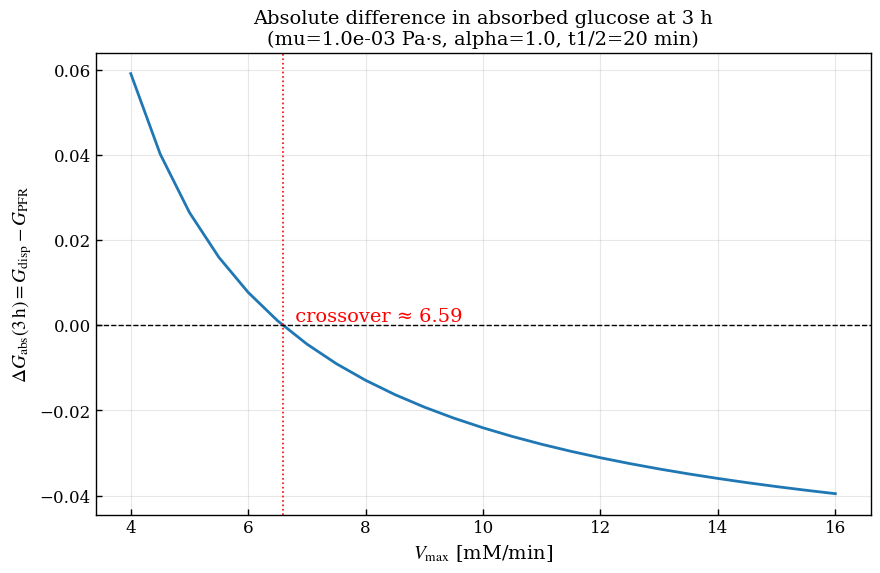

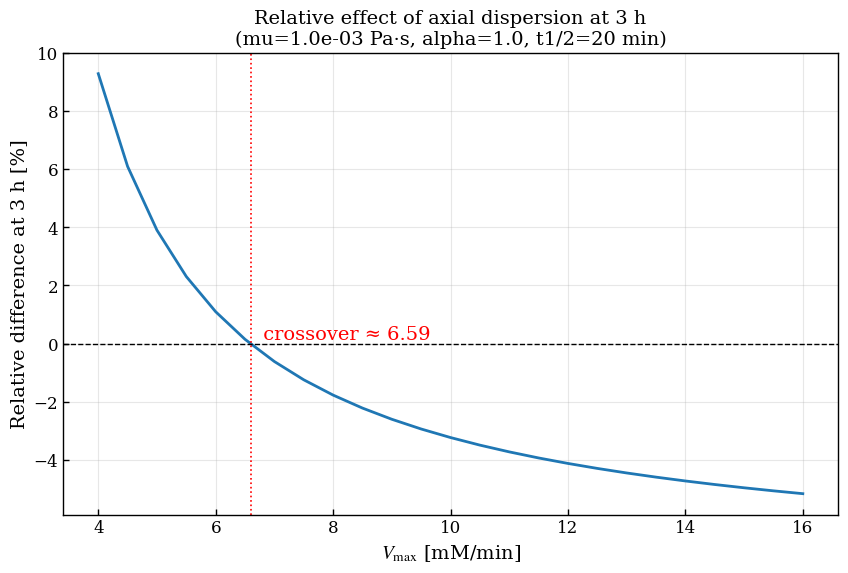

Saved:
  Results/vmax_crossover_absdiff.png
  Results/vmax_crossover_reldiff.png
  Results/vmax_crossover_data.npz


In [ ]:
# =============================================================================
# Vmax crossover sweep at fixed physiological conditions
# Compares:
#   dispersion case  : physical Pe(mu, alpha)
#   ideal PFR case   : same model, same parameters, but Pe = 5000
#
# Output:
#   ΔG_abs(3h)   = G_abs_disp(3h) - G_abs_PFR(3h)
#   rel_diff(3h) = ΔG_abs / G_abs_PFR
# =============================================================================

import numpy as np
import matplotlib.pyplot as plt
import os
from joblib import Parallel, delayed
from tqdm import tqdm

# -----------------------------------------------------------------------------
# 1) Clean up tau_emptying naming: use an explicit conversion function
# -----------------------------------------------------------------------------
def tau_emptying_from_minutes(t_half_min: float) -> float:
    """
    Convert physical gastric half-time [min] to nondimensional tau_emptying.
    """
    gamma = np.log(2.0) / (t_half_min * 60.0)   # [1/s]
    return gamma * (L / u)

# -----------------------------------------------------------------------------
# 2) Fixed physical conditions for this sweep
# -----------------------------------------------------------------------------
mu_fixed = 1e-3          # water viscosity [Pa.s]
alpha_fixed = 1.0        # choose one alpha and keep it fixed
t_half_min_fixed = 20.0  # physical gastric half-time [min]
tau_empty_val = tau_emptying_from_minutes(t_half_min_fixed)

Pe_fixed_pfr = 5000.0    # near-plug-flow benchmark
nx_sweep = 400
rtol_sweep = 1e-6
atol_sweep = 1e-9
tau_end_cap = 10.0       # safety cap in nondimensional time
vmax_vals = np.linspace(4.0, 16.0, 25)

# -----------------------------------------------------------------------------
# 3) Single-point runner
# -----------------------------------------------------------------------------
def run_vmax_point(vmax_mM_per_min: float,
                   mu: float = 1e-3,
                   alpha: float = 1.0,
                   t_half_min: float = 20.0,
                   Pe_pfr: float = 5000.0,
                   nx: int = 400,
                   rtol: float = 1e-6,
                   atol: float = 1e-9):
    """
    Run one Vmax point at fixed geometry/viscosity/emptying.
    Returns dispersion and PFR absorbed glucose at 3 h, plus diagnostics.
    """
    tau_empty_local = tau_emptying_from_minutes(t_half_min)
    tauR = tau_R_from_Vmax(vmax_mM_per_min, C0_mM)

    # Dispersion case: physical Da and Pe from mu, alpha
    Da_val, Pe_disp = transfer_and_pe_from_mu(mu, alpha)

    # ---- Dispersion run ----
    tau_end_dimless = hours_to_tau(4.0)
    for _ in range(10):
        res_disp = simulate_model3_conservative(
            tau_transfer_val=Da_val,
            tau_empty_val=tau_empty_local,
            tau_R=tauR,
            KmII=KmII,
            tau_end=tau_end_dimless,
            Pe_override=Pe_disp,
            nx_override=nx,
            rtol=rtol,
            atol=atol
        )
        if res_disp["t_h"].size == 0 or res_disp["t_h"][-1] >= 3.0:
            break
        tau_end_dimless = min(tau_end_dimless * 1.5, tau_end_cap)

    t_h_disp = res_disp["t_h"]
    Gabs_disp = res_disp["absorbed_fraction"]
    Gabs_disp_3h = np.interp(3.0, t_h_disp, Gabs_disp) if t_h_disp.size > 0 else np.nan

    # ---- PFR benchmark run ----
    tau_end_dimless = hours_to_tau(4.0)
    for _ in range(10):
        res_pfr = simulate_model3_conservative(
            tau_transfer_val=Da_val,      # same Da / tau_transfer
            tau_empty_val=tau_empty_local, # same emptying
            tau_R=tauR,                    # same reaction
            KmII=KmII,
            tau_end=tau_end_dimless,
            Pe_override=Pe_pfr,            # only Pe changes
            nx_override=nx,
            rtol=rtol,
            atol=atol
        )
        if res_pfr["t_h"].size == 0 or res_pfr["t_h"][-1] >= 3.0:
            break
        tau_end_dimless = min(tau_end_dimless * 1.5, tau_end_cap)

    t_h_pfr = res_pfr["t_h"]
    Gabs_pfr = res_pfr["absorbed_fraction"]
    Gabs_pfr_3h = np.interp(3.0, t_h_pfr, Gabs_pfr) if t_h_pfr.size > 0 else np.nan

    # ---- Differences ----
    abs_diff_3h = Gabs_disp_3h - Gabs_pfr_3h
    rel_diff_3h = abs_diff_3h / Gabs_pfr_3h if np.isfinite(Gabs_pfr_3h) and abs(Gabs_pfr_3h) > 1e-14 else np.nan

    return {
        "Vmax": vmax_mM_per_min,
        "Gabs_disp_3h": Gabs_disp_3h,
        "Gabs_pfr_3h": Gabs_pfr_3h,
        "abs_diff_3h": abs_diff_3h,
        "rel_diff_3h": rel_diff_3h,
        "tauR": tauR,
        "Pe_disp": Pe_disp,
        "Da": Da_val,
        "tau_empty_val": tau_empty_local,
        "mb_err_disp": res_disp.get("max_err", np.nan),
        "mb_err_pfr": res_pfr.get("max_err", np.nan),
    }

# -----------------------------------------------------------------------------
# 4) Run the sweep
# -----------------------------------------------------------------------------
results_list = Parallel(n_jobs=-1)(
    delayed(run_vmax_point)(
        vmax_mM_per_min=vmax,
        mu=mu_fixed,
        alpha=alpha_fixed,
        t_half_min=t_half_min_fixed,
        Pe_pfr=Pe_fixed_pfr,
        nx=nx_sweep,
        rtol=rtol_sweep,
        atol=atol_sweep
    )
    for vmax in tqdm(vmax_vals, desc="Vmax sweep")
)

# Convert to arrays
Gabs_disp_3h = np.array([r["Gabs_disp_3h"] for r in results_list])
Gabs_pfr_3h  = np.array([r["Gabs_pfr_3h"]  for r in results_list])
abs_diff_3h  = np.array([r["abs_diff_3h"]  for r in results_list])
rel_diff_3h  = np.array([r["rel_diff_3h"]  for r in results_list])
tauR_vals    = np.array([r["tauR"]         for r in results_list])
Pe_disp_vals = np.array([r["Pe_disp"]      for r in results_list])
Da_vals      = np.array([r["Da"]           for r in results_list])
mb_err_disp  = np.array([r["mb_err_disp"]  for r in results_list])
mb_err_pfr   = np.array([r["mb_err_pfr"]   for r in results_list])

# -----------------------------------------------------------------------------
# 5) Detect sign change / estimate crossover
# -----------------------------------------------------------------------------
sign_change = np.any(np.sign(abs_diff_3h[:-1]) != np.sign(abs_diff_3h[1:]))
cross_vmax = np.nan

if sign_change:
    idx = np.where(np.sign(abs_diff_3h[:-1]) != np.sign(abs_diff_3h[1:]))[0][0]
    x0, x1 = vmax_vals[idx], vmax_vals[idx + 1]
    y0, y1 = abs_diff_3h[idx], abs_diff_3h[idx + 1]
    if abs(y1 - y0) > 1e-14:
        cross_vmax = x0 - y0 * (x1 - x0) / (y1 - y0)

# -----------------------------------------------------------------------------
# 6) Diagnostics
# -----------------------------------------------------------------------------
print("=" * 72)
print("Vmax crossover sweep diagnostics")
print(f"Fixed conditions:")
print(f"  mu                = {mu_fixed:.3e} Pa.s")
print(f"  alpha             = {alpha_fixed}")
print(f"  t_half            = {t_half_min_fixed:.1f} min")
print(f"  tau_emptying      = {tau_empty_val:.6g} (dimensionless)")
print(f"  Pe_fixed_pfr      = {Pe_fixed_pfr:.1f}")
print(f"  Vmax range        = {vmax_vals.min():.2f} .. {vmax_vals.max():.2f} mM/min")
print()
print(f"abs_diff_3h range   = [{np.nanmin(abs_diff_3h):.6g}, {np.nanmax(abs_diff_3h):.6g}]")
print(f"rel_diff_3h range   = [{100*np.nanmin(rel_diff_3h):.3f}%, {100*np.nanmax(rel_diff_3h):.3f}%]")
print(f"tauR range          = [{np.nanmin(tauR_vals):.6g}, {np.nanmax(tauR_vals):.6g}]")
print(f"Pe_disp range       = [{np.nanmin(Pe_disp_vals):.6g}, {np.nanmax(Pe_disp_vals):.6g}]")
print(f"Da range            = [{np.nanmin(Da_vals):.6g}, {np.nanmax(Da_vals):.6g}]")
print(f"max MB err (disp)   = {np.nanmax(mb_err_disp):.3e}")
print(f"max MB err (PFR)    = {np.nanmax(mb_err_pfr):.3e}")
print(f"Sign change occurs? = {sign_change}")
if sign_change:
    print(f"Estimated crossover Vmax ≈ {cross_vmax:.4f} mM/min")
print("=" * 72)

# -----------------------------------------------------------------------------
# 7) Plot A: absolute difference
# -----------------------------------------------------------------------------
fig1, ax1 = plt.subplots(figsize=(10, 6))
ax1.plot(vmax_vals, abs_diff_3h, lw=2)
ax1.axhline(0.0, color="k", lw=1, linestyle="--")
ax1.set_xlabel(r"$V_{\max}$ [mM/min]")
ax1.set_ylabel(r"$\Delta G_{\mathrm{abs}}(3\,\mathrm{h}) = G_{\mathrm{disp}} - G_{\mathrm{PFR}}$")
ax1.set_title(
    "Absolute difference in absorbed glucose at 3 h\n"
    f"(mu={mu_fixed:.1e} Pa·s, alpha={alpha_fixed}, t1/2={t_half_min_fixed:.0f} min)"
)
ax1.grid(True, alpha=0.3)

if sign_change and np.isfinite(cross_vmax):
    ax1.axvline(cross_vmax, color="r", lw=1.2, linestyle=":")
    ax1.text(cross_vmax, 0.0, f"  crossover ≈ {cross_vmax:.2f}", color="r", va="bottom")

# -----------------------------------------------------------------------------
# 8) Plot B: relative difference in percent
# -----------------------------------------------------------------------------
fig2, ax2 = plt.subplots(figsize=(10, 6))
ax2.plot(vmax_vals, 100.0 * rel_diff_3h, lw=2)
ax2.axhline(0.0, color="k", lw=1, linestyle="--")
ax2.set_xlabel(r"$V_{\max}$ [mM/min]")
ax2.set_ylabel(r"Relative difference at 3 h [%]")
ax2.set_title(
    "Relative effect of axial dispersion at 3 h\n"
    f"(mu={mu_fixed:.1e} Pa·s, alpha={alpha_fixed}, t1/2={t_half_min_fixed:.0f} min)"
)
ax2.grid(True, alpha=0.3)

if sign_change and np.isfinite(cross_vmax):
    ax2.axvline(cross_vmax, color="r", lw=1.2, linestyle=":")
    ax2.text(cross_vmax, 0.0, f"  crossover ≈ {cross_vmax:.2f}", color="r", va="bottom")

# -----------------------------------------------------------------------------
# 9) Save outputs
# -----------------------------------------------------------------------------
os.makedirs("Results", exist_ok=True)

fig1.savefig("Results/vmax_crossover_absdiff.png", dpi=150, bbox_inches="tight")
fig2.savefig("Results/vmax_crossover_reldiff.png", dpi=150, bbox_inches="tight")

np.savez(
    "Results/vmax_crossover_data.npz",
    vmax_vals=vmax_vals,
    Gabs_disp_3h=Gabs_disp_3h,
    Gabs_pfr_3h=Gabs_pfr_3h,
    abs_diff_3h=abs_diff_3h,
    rel_diff_3h=rel_diff_3h,
    tauR_vals=tauR_vals,
    Pe_disp_vals=Pe_disp_vals,
    Da_vals=Da_vals,
    mu_fixed=mu_fixed,
    alpha_fixed=alpha_fixed,
    t_half_min_fixed=t_half_min_fixed,
    tau_empty_val=tau_empty_val,
    Pe_fixed_pfr=Pe_fixed_pfr,
    cross_vmax=cross_vmax,
    sign_change=sign_change,
    mb_err_disp=mb_err_disp,
    mb_err_pfr=mb_err_pfr,
)

plt.show()

print("Saved:")
print("  Results/vmax_crossover_absdiff.png")
print("  Results/vmax_crossover_reldiff.png")
print("  Results/vmax_crossover_data.npz")

Small test: alpha=30, 8 mu points


test: 100%|██████████| 8/8 [00:00<00:00, 159.29it/s]


  Da range: 0.006549 .. 3.04
  Pe range: 0.13 .. 1.3e+03
  Gabs at mu=1e-3: 0.7426, at mu=10: 0.002726
  Trend (should decrease with mu): 0.7426 -> 0.002726



alpha: 100%|██████████| 1/1 [00:40<00:00, 40.66s/it]


alpha=1: Da [0.006549, 3.04], Pe [0.00015, 1.5], Gabs_3h at mu=1e-3: 0.6963, at mu=10: 0.00263


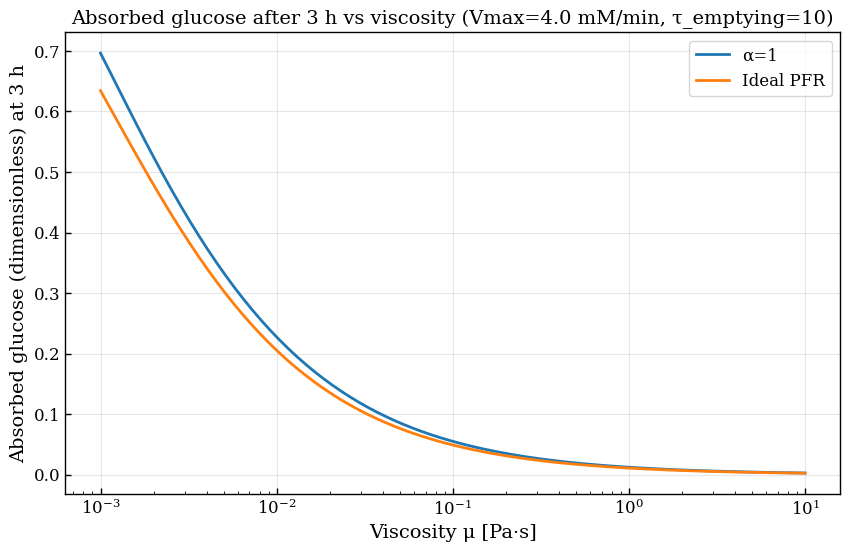

Saved Results/moxon_mu_sweep_alpha_overlay.png and Results/moxon_mu_sweep_data.npz


In [ ]:
# =============================================================================
# Moxon-style viscosity sweep: absorbed glucose after 3 h vs μ, for alpha ∈ {1, 600} + Pe=5000 (α=1)
# =============================================================================
from joblib import Parallel, delayed
from tqdm import tqdm
import os

tau_emptying = 10
Vmax_baseline = 4.0
nx = 400
rtol, atol = 1e-6, 1e-9
tau_end_cap = 10.0


def run_mu_point(mu, alpha, tau_emptying_val, Vmax_baseline=9.0, nx=400, rtol=1e-6, atol=1e-9):
    """Run one (mu, alpha) point, return absorbed at 3h plus debug info."""
    tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)
    wall_strength_Da, Pe_val = transfer_and_pe_from_mu(mu, alpha)
    tau_end_dimless = hours_to_tau(4.0)  # start
    for _ in range(10):
        res = simulate_model3_conservative(
            wall_strength_Da, tau_emptying_val, tauR, KmII, tau_end_dimless,
            Pe_override=Pe_val, nx_override=nx, rtol=rtol, atol=atol
        )
        if res["t_h"].size == 0 or res["t_h"][-1] >= 3.0:
            break
        tau_end_dimless = min(tau_end_dimless * 1.5, tau_end_cap)
    t_h = res["t_h"]
    Gabs = res["absorbed_fraction"]
    Gabs_3h = np.interp(3.0, t_h, Gabs) if t_h.size > 0 else np.nan
    return Gabs_3h, wall_strength_Da, Pe_val


def run_mu_point_fixedPe(mu, tau_emptying_val, Vmax_baseline=9.0, nx=400,
                         rtol=1e-6, atol=1e-9, Pe_fixed=5000.0):
    """
    Run one point where:
      - Da comes from transfer_and_pe_from_mu(mu, alpha=1)
      - Pe is forced to Pe_fixed (default 5000)
    """
    tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)
    wall_strength_Da, _ = transfer_and_pe_from_mu(mu, 1)  # alpha=1 for Da
    Pe_val = Pe_fixed
    tau_end_dimless = hours_to_tau(4.0)  # start
    for _ in range(10):
        res = simulate_model3_conservative(
            wall_strength_Da, tau_emptying_val, tauR, KmII, tau_end_dimless,
            Pe_override=Pe_val, nx_override=nx, rtol=rtol, atol=atol
        )
        if res["t_h"].size == 0 or res["t_h"][-1] >= 3.0:
            break
        tau_end_dimless = min(tau_end_dimless * 1.5, tau_end_cap)
    t_h = res["t_h"]
    Gabs = res["absorbed_fraction"]
    Gabs_3h = np.interp(3.0, t_h, Gabs) if t_h.size > 0 else np.nan
    return Gabs_3h, wall_strength_Da, Pe_val


# 1) Small test sweep (8 points, alpha=30) to validate monotonic trend
print("=" * 60)
print("Small test: alpha=30, 8 mu points")
mu_test = np.logspace(-3, 1, 8)
out = Parallel(n_jobs=-1)(
    delayed(run_mu_point)(mu, 30.0, tau_emptying) for mu in tqdm(mu_test, desc="test")
)
Gabs_test = np.array([x[0] for x in out])
Da_test = np.array([x[1] for x in out])
Pe_test = np.array([x[2] for x in out])
print(f"  Da range: {Da_test.min():.4g} .. {Da_test.max():.4g}")
print(f"  Pe range: {Pe_test.min():.2g} .. {Pe_test.max():.2g}")
print(f"  Gabs at mu=1e-3: {Gabs_test[0]:.4g}, at mu=10: {Gabs_test[-1]:.4g}")
print(f"  Trend (should decrease with mu): {Gabs_test[0]:.4g} -> {Gabs_test[-1]:.4g}")
print()

# 2) Full sweep: alpha_list and mu_vals
alpha_list = [1]
mu_vals = np.logspace(-3, 1, 80)

results = {}
for alpha in tqdm(alpha_list, desc="alpha"):
    out = Parallel(n_jobs=-1)(
        delayed(run_mu_point)(mu, alpha, tau_emptying, Vmax_baseline, nx, rtol, atol)
        for mu in tqdm(mu_vals, desc=f"alpha={alpha}", leave=False)
    )
    Gabs_3h = np.array([x[0] for x in out])
    Da_arr = np.array([x[1] for x in out])
    Pe_arr = np.array([x[2] for x in out])
    results[alpha] = {"Gabs_3h": Gabs_3h, "Da": Da_arr, "Pe": Pe_arr}

    # Debug output
    print(f"alpha={alpha}: Da [{Da_arr.min():.4g}, {Da_arr.max():.4g}], "
          f"Pe [{Pe_arr.min():.2g}, {Pe_arr.max():.2g}], "
          f"Gabs_3h at mu=1e-3: {Gabs_3h[0]:.4g}, at mu=10: {Gabs_3h[-1]:.4g}")

# 2b) Pe=5000 override with alpha=1 for Da
Pe_fixed = 5000.0
out_pe = Parallel(n_jobs=-1)(
    delayed(run_mu_point_fixedPe)(mu, tau_emptying, Vmax_baseline, nx, rtol, atol, Pe_fixed)
    for mu in tqdm(mu_vals, desc="Pe=5000", leave=False)
)
Gabs_3h_pe = np.array([x[0] for x in out_pe])
Da_arr_pe = np.array([x[1] for x in out_pe])
Pe_arr_pe = np.array([x[2] for x in out_pe])
results["Pe5000"] = {"Gabs_3h": Gabs_3h_pe, "Da": Da_arr_pe, "Pe": Pe_arr_pe}

# 3) Plot
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
for alpha in alpha_list:
    ax.semilogx(mu_vals, results[alpha]["Gabs_3h"], "-", lw=2, label=f"α={alpha}")
# Third line: Pe fixed at 5000, Da from alpha=1
ax.semilogx(mu_vals, results["Pe5000"]["Gabs_3h"], "-", lw=2, label="Ideal PFR")
ax.set_xlabel(r"Viscosity μ [Pa·s]")
ax.set_ylabel(r"Absorbed glucose (dimensionless) at 3 h")
ax.set_title(
    f"Absorbed glucose after 3 h vs viscosity "
    f"(Vmax={Vmax_baseline} mM/min, τ_emptying={tau_emptying})"
)
ax.legend()
ax.grid(True, alpha=0.3)

# 4) Save
os.makedirs("Results", exist_ok=True)
fig.savefig("Results/moxon_mu_sweep_alpha_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

# 5) Save raw data (npz) including Pe=5000 series
np.savez(
    "Results/moxon_mu_sweep_data.npz",
    mu=mu_vals,
    alpha_list=np.array(alpha_list),
    **{f"Gabs_alpha{a}": results[a]["Gabs_3h"] for a in alpha_list},
    **{f"Da_alpha{a}": results[a]["Da"] for a in alpha_list},
    **{f"Pe_alpha{a}": results[a]["Pe"] for a in alpha_list},
    Gabs_Pe5000=results["Pe5000"]["Gabs_3h"],
    Da_Pe5000=results["Pe5000"]["Da"],
    Pe_Pe5000=results["Pe5000"]["Pe"],
)
print("Saved Results/moxon_mu_sweep_alpha_overlay.png and Results/moxon_mu_sweep_data.npz")

Max relative difference: 12.87%
Min relative difference: 9.58%


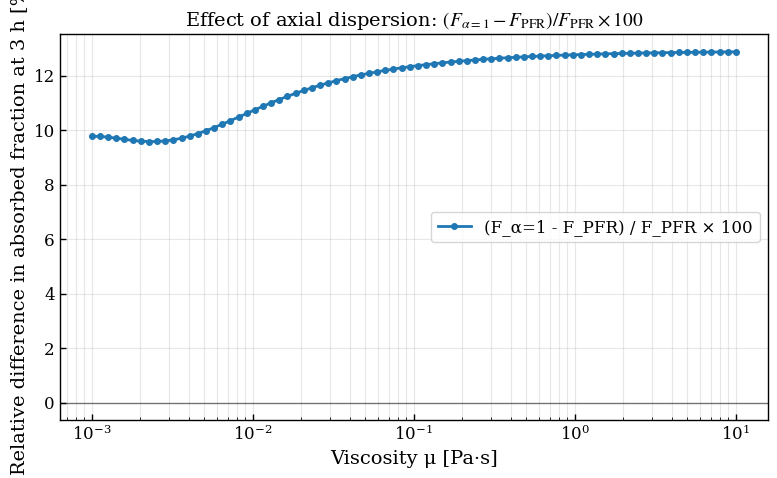

In [ ]:
# ============================================================================
# Negligibility of axial dispersion: relative difference vs μ
# PFR is approximated by Pe = 5000 (results["Pe5000"])
# ΔF = F_alpha1 - F_PFR ;  Rel(%) = 100 * ΔF / F_PFR
# ============================================================================

# Extract curves
F_alpha1 = results[1]["Gabs_3h"]              # ADM, α = 1
F_PFR = results["Pe5000"]["Gabs_3h"]          # PFR ≈ Pe = 5000

# Compute absolute and relative differences
Delta_F = F_alpha1 - F_PFR
rel_diff_pct = 100.0 * Delta_F / F_PFR       # (%)  ΔF / F_PFR * 100

# Optional: print a quick summary
print(f"Max relative difference: {np.nanmax(rel_diff_pct):.2f}%")
print(f"Min relative difference: {np.nanmin(rel_diff_pct):.2f}%")

# Plot on semi-log μ axis
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.semilogx(mu_vals, rel_diff_pct, "-o", lw=2, ms=4, label="(F_α=1 - F_PFR) / F_PFR × 100")

ax.set_xlabel(r"Viscosity μ [Pa·s]")
ax.set_ylabel(r"Relative difference in absorbed fraction at 3 h [%]")
ax.set_title(r"Effect of axial dispersion: $(F_{\alpha=1} - F_{\mathrm{PFR}})/F_{\mathrm{PFR}} \times 100$")
ax.axhline(0.0, color="k", lw=1, alpha=0.5)
ax.grid(True, which="both", alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

Max absolute difference: 0.0620
Min absolute difference: 0.0003


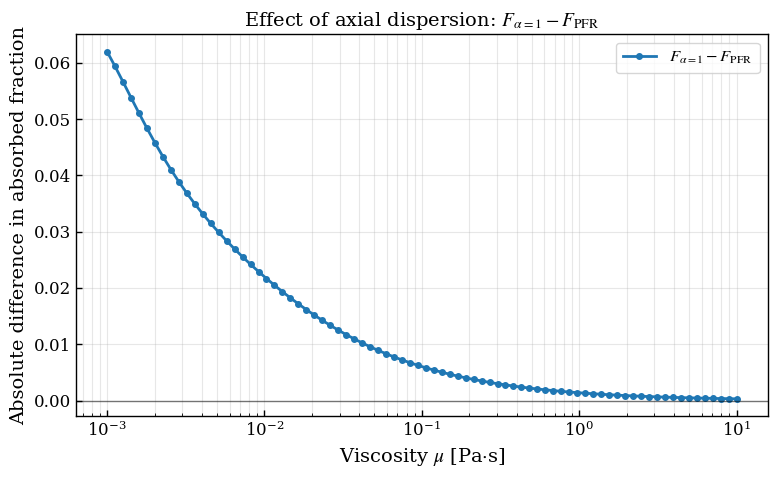

In [ ]:
# ============================================================================
# Negligibility of axial dispersion: absolute difference vs μ
# PFR is approximated by Pe = 5000 (results["Pe5000"])
# ΔF = F_alpha1 - F_PFR
# ============================================================================

# Extract curves
F_alpha1 = results[1]["Gabs_3h"]              # ADM, α = 1
F_PFR = results["Pe5000"]["Gabs_3h"]          # PFR ≈ Pe = 5000

# Compute absolute difference
Delta_F = F_alpha1 - F_PFR

# Optional: print summary
print(f"Max absolute difference: {np.nanmax(Delta_F):.4f}")
print(f"Min absolute difference: {np.nanmin(Delta_F):.4f}")

# Plot on semi-log μ axis
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.semilogx(mu_vals, Delta_F, "-o", lw=2, ms=4,
            label=r"$F_{\alpha=1} - F_{\mathrm{PFR}}$")

ax.set_xlabel(r"Viscosity $\mu$ [Pa$\cdot$s]")
ax.set_ylabel(r"Absolute difference in absorbed fraction")
ax.set_title(r"Effect of axial dispersion: $F_{\alpha=1} - F_{\mathrm{PFR}}$")

ax.axhline(0.0, color="k", lw=1, alpha=0.5)
ax.grid(True, which="both", alpha=0.3)
ax.legend()

plt.tight_layout()
plt.show()

In [ ]:
Pe_vals = 1.5 * np.logspace(-1, 3, 12)      
print(Pe_vals)

[1.50000000e-01 3.46519455e-01 8.00504885e-01 1.84927011e+00
 4.27205380e+00 9.86899837e+00 2.27986662e+01 5.26678760e+01
 1.21669625e+02 2.81072613e+02 6.49314192e+02 1.50000000e+03]


## 2D Parameter Sweep: Pe vs τ_transfer (similar to fig4c)
Analyze the interaction between **Axial Dispersion** ($Pe$) and **Wall Uptake** ($\tau_{\mathrm{transfer}}$) at fixed gastric emptying slices ($\tau_{\mathrm{emptying}}$). Fraction absorbed $F$ at $\tau = 1.0$; reaction rate held at high baseline (e.g. $V_{\max}=16$) so the system is not reaction-limited.

In [ ]:
# =============================================================================
# FULL SCRIPT: viscosity μ vs gastric emptying τ_emptying sweep (for Vmax ∈ {4,9,16})
# Uses transfer_and_pe_from_mu(mu, alpha) -> (wall_strength_Da, Pe_L)
# =============================================================================

from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# =============================================================================
# Physical constants + baseline SI geometry / flow (Moxon-style)
# =============================================================================
kB = 1.380649e-23          # [J/K]
T_body = 310.0             # [K]
r0_glucose = 0.38e-9       # [m] glucose molecular radius used in Moxon-style setup

L_SI = 2.85                # [m]
r_m = 1.8e-2               # [m]
d_int = 2.0 * r_m          # [m]
u_bar = 1.7e-4             # [m/s]
f_surface = 12.0           # [-]

# Concentration scale for tau_R (adjust if your model uses a different initial scaling)
C0_mM = 555.0              # [mM]

def tau_R_from_Vmax(Vmax_mM_min: float, C0_mM: float = C0_mM) -> float:
    """
    Dimensionless reaction timescale:
        tau_R = (L/u) * (Vmax / C0)
    with Vmax in mM/s and C0 in mM.
    """
    Vmax_mM_s = float(Vmax_mM_min) / 60.0
    return (L_SI / u_bar) * (Vmax_mM_s / float(C0_mM))

def transfer_and_pe_from_mu(mu: float, alpha: float):
    """
    Returns:
      wall_strength_Da, peL

    Physics:
      D (Stokes–Einstein): D = kB T / (6π μ r0)
      K (Carbonell/Moxon): K = 1.62 * (u D^2/(L d))^(1/3)
      wall_strength_Da:    (2 f K / r_m) * (L/u)
      Pe_d:                u (d/alpha) / D
      Taylor–Aris:         D_ax = D * (1 + Pe_d^2/192)
      Pe_L:                u L / D_ax
    """
    mu = float(mu)
    alpha = float(alpha)
    if mu <= 0.0:
        raise ValueError("mu must be > 0 [Pa·s].")
    if alpha <= 0.0:
        raise ValueError("alpha must be > 0.")

    # 1) Molecular diffusion
    D = (kB * T_body) / (6.0 * np.pi * mu * r0_glucose)  # [m^2/s]

    # 2) Mass transfer coefficient
    K = 1.62 * (u_bar * D**2 / (L_SI * d_int))**(1.0 / 3.0)  # [m/s]

    # 3) Dimensionless wall strength (matches your prior tau_transfer construction)
    wall_strength_Da = (2.0 * f_surface * K / r_m) * (L_SI / u_bar)  # [-]

    # 4) Peclet using alpha-adjusted diameter + Taylor–Aris correction to D_ax
    d_eff = d_int / alpha
    Pe_d = (u_bar * d_eff) / D
    D_ax = D * (1.0 + (Pe_d**2) / 192.0)
    peL = (u_bar * L_SI) / D_ax

    return wall_strength_Da, peL


# =============================================================================
# USER MODEL HOOKS (must exist in your environment)
# =============================================================================
# You must already have:
#   - simulate_model3_conservative(...)
#   - KmII defined (dimensionless Km = Km / C0)
#
# Example:
# KmII = Km_mM / C0_mM
#
# If these are missing, this script will raise NameError.
# =============================================================================


# =============================================================================
# 2D Parameter Sweep: viscosity μ vs gastric emptying τ_emptying, for multiple Vmax
# =============================================================================

# Independent grids
mu_vals = np.logspace(-3, 1, 25)        # [Pa·s]
phi_slices = np.logspace(-1, 2, 20)     # τ_emptying

assert np.all(mu_vals > 0), "mu_vals must be positive and in Pa·s, not cP."

# Solver / model settings
tau_end = 1.05
rtol_sweep = 1e-6
atol_sweep = 1e-9
nx_sweep = 400

alpha_fixed = 1.0
Vmax_vals = [4.0, 9.0, 16.0]  # [mM/min]

# Storage: one F_data per Vmax
F_by_vmax = []

for Vmax_baseline in Vmax_vals:
    print(f"Vmax = {Vmax_baseline} mM/min, alpha = {alpha_fixed} ...")
    tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)

    # Sanity check ranges
    wall_list, peL_list = [], []
    for mu in mu_vals:
        wall_strength_Da, peL = transfer_and_pe_from_mu(mu, alpha_fixed)
        wall_list.append(wall_strength_Da)
        peL_list.append(peL)
    print("  wall_strength_Da range:", float(min(wall_list)), float(max(wall_list)))
    print("  Pe_L range:", float(min(peL_list)), float(max(peL_list)))

    F_data = np.zeros((len(phi_slices), len(mu_vals)), dtype=float)

    def _run_point(phi_idx: int, mu_idx: int):
        tau_em = float(phi_slices[phi_idx])
        mu = float(mu_vals[mu_idx])

        wall_strength_Da, Pe_val = transfer_and_pe_from_mu(mu, alpha_fixed)

        res = simulate_model3_conservative(
            wall_strength_Da, tau_em, tauR, KmII, tau_end,
            Pe_override=Pe_val,
            nx_override=nx_sweep,
            rtol=rtol_sweep,
            atol=atol_sweep,
        )

        # fraction absorbed at τ=1
        F_val = float(np.clip(np.interp(1.0, res["tau"], res["absorbed_fraction"]), 0.0, 1.0))
        return phi_idx, mu_idx, F_val

    index_pairs = [(k, i) for k in range(len(phi_slices)) for i in range(len(mu_vals))]

    results = Parallel(n_jobs=-1)(
        delayed(_run_point)(k, i)
        for (k, i) in tqdm(
            index_pairs,
            total=len(index_pairs),
            desc=f"Computing F_data [Vmax={Vmax_baseline}]",
        )
    )

    for k, i, F_val in results:
        F_data[k, i] = F_val

    F_by_vmax.append(F_data)

print("All Vmax sweeps complete.")


# =============================================================================
# Plot: 1×3 panel with shared colorbar
# =============================================================================
levels = np.linspace(0.0, 1.0, 51)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes = axes.flatten()

cf = None
for ax, Vmax_baseline, F_data in zip(axes, Vmax_vals, F_by_vmax):
    cf = ax.contourf(
        mu_vals, phi_slices, F_data,
        levels=levels, cmap=cmap, norm=norm, extend="neither",
    )
    cs = ax.contour(
        mu_vals, phi_slices, F_data,
        levels=[0.2, 0.4, 0.6, 0.8, 0.999999999],
        colors="k", linewidths=0.8,
    )
    ax.clabel(cs, fmt="%.1f", fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(mu_vals.min(), mu_vals.max())
    ax.set_ylim(phi_slices.min(), phi_slices.max())

    ax.set_xlabel(r"Viscosity, $\mu$ [Pa$\cdot$s]")
    ax.set_ylabel(r"$\tau_{\mathrm{emptying}}$")
    ax.set_title(rf"$V_{{\max}}$ = {Vmax_baseline:g} mM/min (alpha = {alpha_fixed:g})")

fig.subplots_adjust(left=0.08, right=0.88, wspace=0.3)

cax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
fig.colorbar(cf, cax=cax, ticks=tick_vals).set_label(
    r"Fraction absorbed at $\tau=1$ (Wall Strength $Da$ Model)"
)

plt.show()

# This is the diagnostic for peclet sweep 


Pe-Da heatmap: 100%|██████████| 900/900 [08:15<00:00,  1.82it/s]


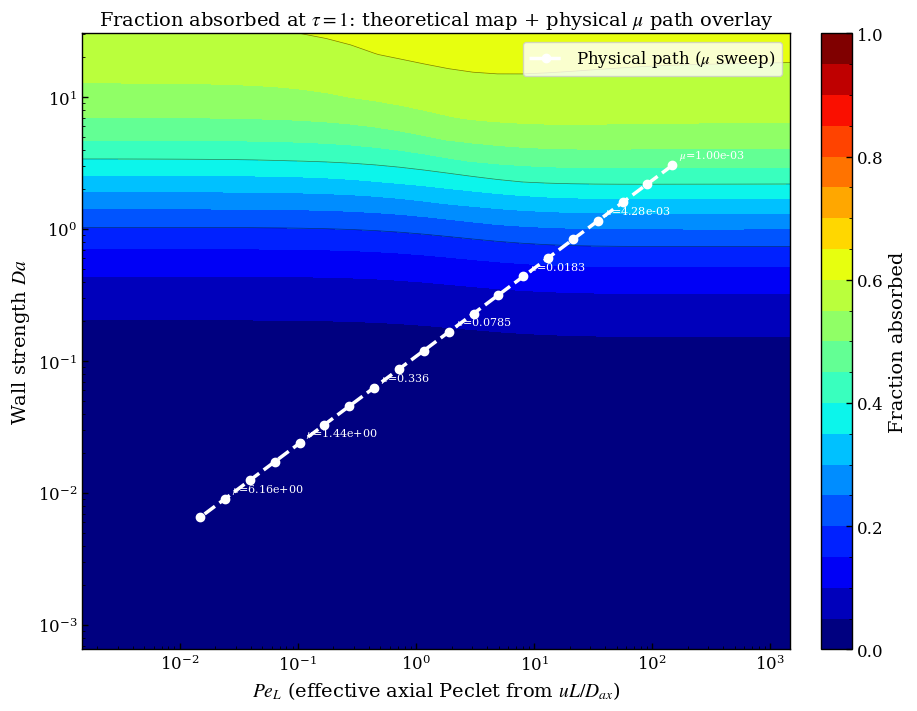

In [ ]:
# Diagnostic: Physical viscosity path overlay on Pe vs Da theoretical map
# Requires: transfer_and_pe_from_mu(mu, alpha), simulate_model3_conservative, KmII, tau_R_from_Vmax, C0_mM

from joblib import Parallel, delayed
from tqdm import tqdm
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl

# --------------------------
# Settings
# --------------------------
alpha_overlay = 10
tau_em = 1.0
tau_end = 1.05
tauR = tau_R_from_Vmax(4.0, C0_mM)

# Physical trace first (so we can size the theory grid correctly)
mu_path = np.logspace(-3, 1, 20)
Pe_path, Da_path = [], []
for mu in mu_path:
    Da_val, Pe_val = transfer_and_pe_from_mu(mu, alpha_overlay)  # returns (Da, Pe_L)
    if np.isfinite(Da_val) and np.isfinite(Pe_val) and (Da_val > 0) and (Pe_val > 0):
        Da_path.append(Da_val)
        Pe_path.append(Pe_val)

Pe_path = np.array(Pe_path, dtype=float)
Da_path = np.array(Da_path, dtype=float)

# If path is empty, stop early with a clear error
if Pe_path.size == 0 or Da_path.size == 0:
    raise RuntimeError("Physical path is empty (nonpositive or nonfinite Pe/Da). Check transfer_and_pe_from_mu outputs.")

# --------------------------
# Build theory grid around the physical path (padding in decades)
# --------------------------
pad_decades = 1.0  # expand range by ~10x on each side
pe_min = 10**(np.log10(Pe_path.min()) - pad_decades)
pe_max = 10**(np.log10(Pe_path.max()) + pad_decades)
da_min = 10**(np.log10(Da_path.min()) - pad_decades)
da_max = 10**(np.log10(Da_path.max()) + pad_decades)

# Also enforce sane global bounds so the map doesn't explode if something goes extreme
pe_min = max(pe_min, 1e-6)
pe_max = min(pe_max, 1e6)
da_min = max(da_min, 1e-6)
da_max = min(da_max, 1e6)

n_grid = 30  # increase if you want smoother contours (cost ~ n_grid^2 solves)
Pe_theory = np.logspace(np.log10(pe_min), np.log10(pe_max), n_grid)
Da_theory = np.logspace(np.log10(da_min), np.log10(da_max), n_grid)

def _run_point_theory(pe_idx, da_idx):
    Pe_val = float(Pe_theory[pe_idx])
    Da_val = float(Da_theory[da_idx])

    res = simulate_model3_conservative(
        Da_val, tau_em, tauR, KmII, tau_end,
        Pe_override=Pe_val, nx_override=400, rtol=1e-6, atol=1e-9
    )
    F = float(np.clip(np.interp(1.0, res["tau"], res["absorbed_fraction"]), 0.0, 1.0))
    return pe_idx, da_idx, F

index_pairs = [(i, j) for i in range(len(Pe_theory)) for j in range(len(Da_theory))]
results = Parallel(n_jobs=-1)(
    delayed(_run_point_theory)(i, j)
    for (i, j) in tqdm(index_pairs, total=len(index_pairs), desc="Pe-Da heatmap")
)

Z = np.zeros((len(Da_theory), len(Pe_theory)), dtype=float)
for i, j, F in results:
    Z[j, i] = F  # Z[Da_idx, Pe_idx] for contourf(Pe, Da, Z)

# --------------------------
# Plot
# --------------------------
levels = np.linspace(0.0, 1.0, 21)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, ax = plt.subplots(figsize=(10, 8))

cf = ax.contourf(Pe_theory, Da_theory, Z, levels=levels, cmap=cmap, norm=norm, extend="neither")
ax.contour(Pe_theory, Da_theory, Z, levels=[0.2, 0.4, 0.6, 0.8], colors="k", linewidths=0.5, alpha=0.5)

# Physical path overlay
ax.plot(Pe_path, Da_path, "w--o", lw=2.5, markersize=6, label="Physical path ($\\mu$ sweep)")

# Annotate ~6 points
step = max(1, len(mu_path) // 6)
for idx in range(0, len(mu_path), step):
    # guard in case some points were filtered
    if idx >= len(Pe_path):
        break
    mu_val = mu_path[idx]
    lbl = f"$\\mu$={mu_val:.3g}" if (0.01 <= mu_val <= 1.0) else f"$\\mu$={mu_val:.2e}"
    ax.annotate(lbl, (Pe_path[idx], Da_path[idx]), fontsize=8, color="white",
                xytext=(5, 5), textcoords="offset points", ha="left")

ax.set_xscale("log")
ax.set_yscale("log")

# Explicit limits so nothing gets clipped
ax.set_xlim(min(Pe_theory.min(), Pe_path.min()), max(Pe_theory.max(), Pe_path.max()))
ax.set_ylim(min(Da_theory.min(), Da_path.min()), max(Da_theory.max(), Da_path.max()))

ax.set_xlabel(r"$Pe_L$ (effective axial Peclet from $uL/D_{ax}$)")
ax.set_ylabel(r"Wall strength $Da$")
ax.set_title(r"Fraction absorbed at $\tau=1$: theoretical map + physical $\mu$ path overlay")
ax.legend(loc="upper right", framealpha=0.8)

# Colorbar (don’t use both tight_layout + manual axes juggling)
cbar = fig.colorbar(cf, ax=ax, fraction=0.046, pad=0.04, ticks=[0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.set_label(r"Fraction absorbed")

plt.show()

NameError: name 'F_data' is not defined

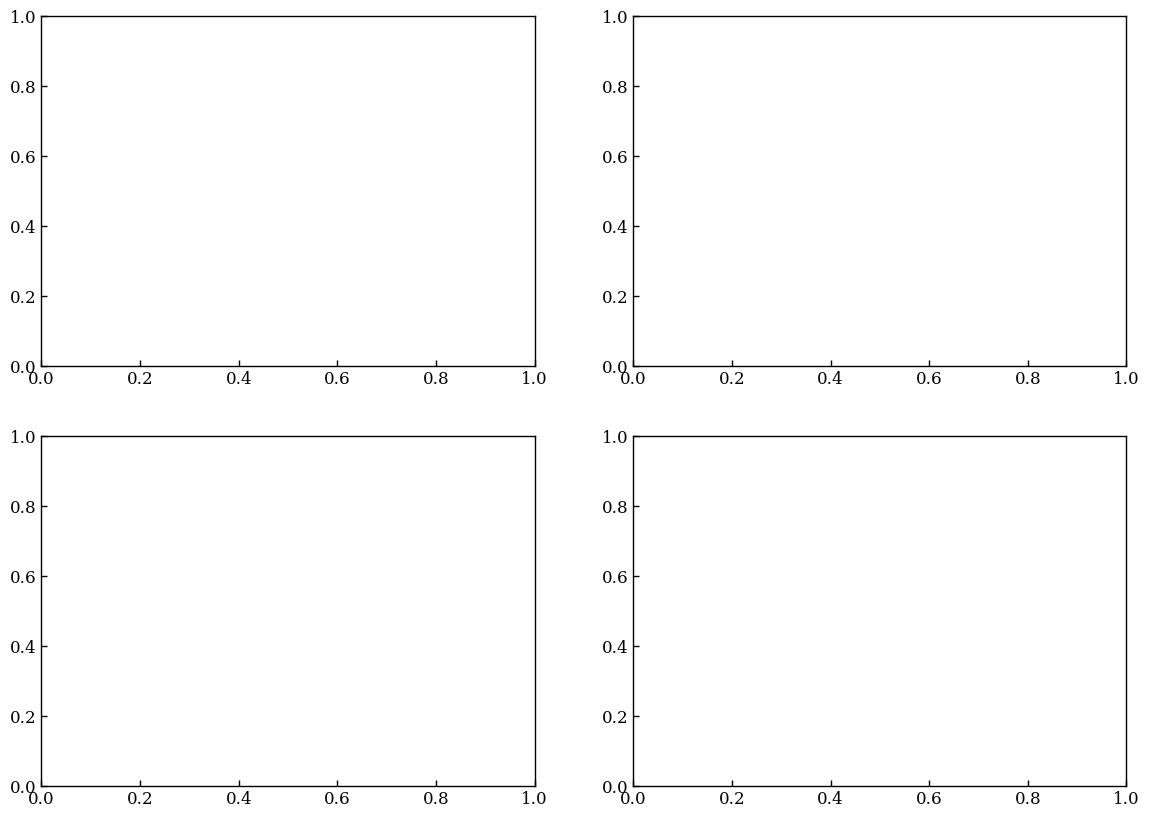

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib as mpl
import matplotlib as mpl
import matplotlib.pyplot as plt# -------------------------
# Choose 4 Peclet values
# -------------------------
# Use 4 log-spaced indices from existing Pe_vals
pe_indices = np.linspace(0, len(Pe_vals)-1, 4, dtype=int)
Pe_panels = Pe_vals[pe_indices]

levels = np.linspace(0.0, 1.0, 21)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cf = None

for ax, pe_idx, Pe_val in zip(axes, pe_indices, Pe_panels):

    # Extract matrix for fixed Pe
    # Shape: (len(tau_emptying), len(tau_transfer))
    Z = F_data[:, :, pe_idx]

    cf = ax.contourf(
        tau_transfer_vals,       # x-axis
        phi_slices,              # y-axis (tau_emptying)
        Z,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="neither"
    )

    cs = ax.contour(
        tau_transfer_vals,
        phi_slices,
        Z,
        levels=[0.2, 0.4, 0.6, 0.8, 0.999999999],
        colors="k",
        linewidths=0.8
    )

    ax.clabel(cs, fmt="%.1f", fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Mass transfer parameter, $\tau_{\mathrm{transfer}}$")
    ax.set_ylabel(r"Gastric emptying parameter, $\tau_{\mathrm{emptying}}$")
    ax.set_title(r"$Pe$ = " + f"{Pe_val:.2g}")

# Shared colorbar
fig.subplots_adjust(right=0.85)

tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(cf, cax=cax, ticks=tick_vals)\
   .set_label(r"Fraction absorbed at $\tau=1$")



IndexError: too many indices for array: array is 2-dimensional, but 3 were indexed

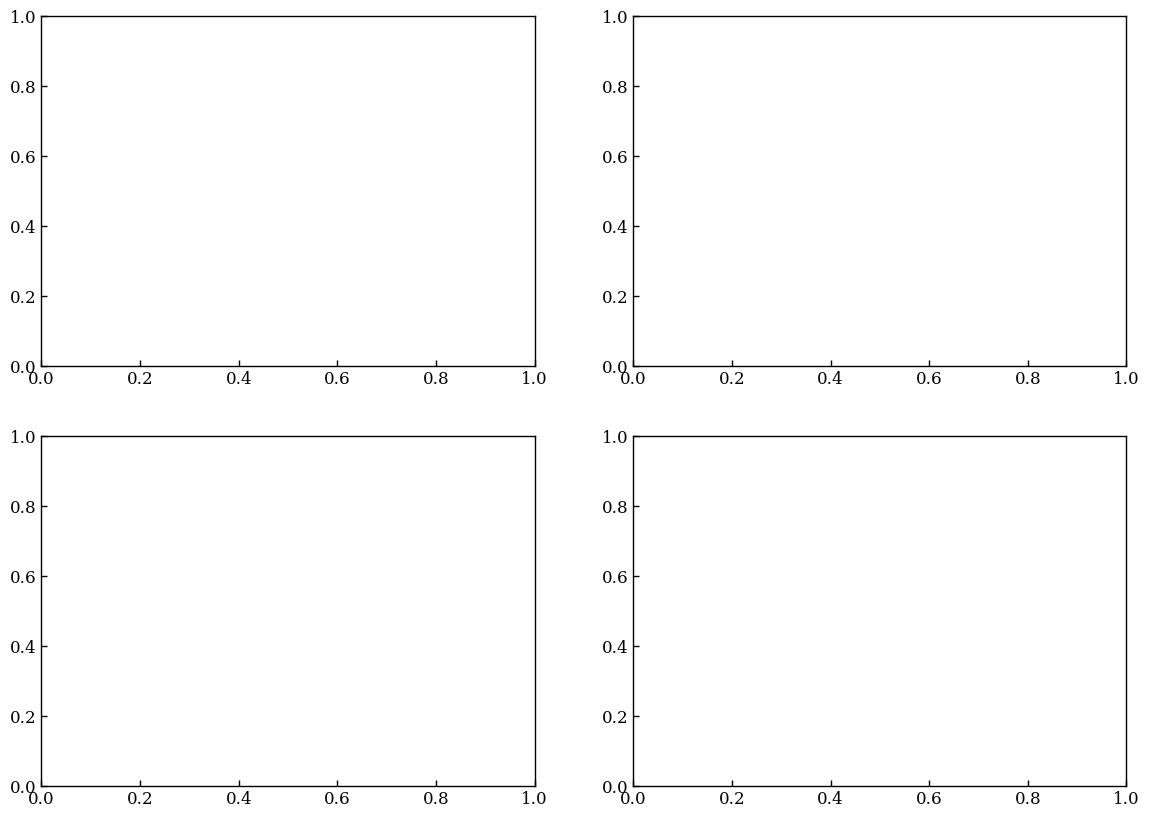

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------
# Choose 4 Peclet values
# -------------------------
# Use 4 log-spaced indices from existing Pe_vals
pe_indices = np.linspace(0, len(Pe_vals)-1, 4, dtype=int)
Pe_panels = Pe_vals[pe_indices]

levels = np.linspace(0.0, 1.0, 21)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cf = None

for ax, pe_idx, Pe_val in zip(axes, pe_indices, Pe_panels):

    # Extract matrix for fixed Pe
    # Shape: (len(tau_emptying), len(tau_transfer))
    Z = F_data[:, :, pe_idx]

    cf = ax.contourf(
        tau_transfer_vals,       # x-axis
        phi_slices,              # y-axis (tau_emptying)
        Z,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="neither"
    )

    cs = ax.contour(
        tau_transfer_vals,
        phi_slices,
        Z,
        levels=[0.2, 0.4, 0.6, 0.8, 0.999999999],
        colors="k",
        linewidths=0.8
    )

    ax.clabel(cs, fmt="%.1f", fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Mass transfer parameter, $\tau_{\mathrm{transfer}}$")
    ax.set_ylabel(r"Gastric emptying parameter, $\tau_{\mathrm{emptying}}$")
    ax.set_title(r"$Pe$ = " + f"{Pe_val:.2g}")

# Shared colorbar
fig.subplots_adjust(right=0.85)

tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(cf, cax=cax, ticks=tick_vals)\
   .set_label(r"Fraction absorbed at $\tau=1$")

plt.show()


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm
import matplotlib as mpl

# 2D Parameter Sweep: Computation Only (run once)

# Sweep setup: Pe (x-axis), tau_transfer (y-axis), tau_emptying held at slices
# Use coarser grids for runtime: 12×12 instead of 25×25
Pe_vals = 1.5 * np.logspace(-1, 3, 12)             # 0.15 → 150
tau_transfer_vals = np.logspace(-1, 2, 12)  # 10^-1 → 10^2 (0.1 to 100 like in fig4c)
phi_slices = [0.1, 1, 10, 100]              # Gastric emptying "slices" (τ_emptying)

# Constant: high physiological reaction baseline (not reaction-limited)
Vmax_baseline = 9.0
# Shorter integration window: just beyond τ=1 for interpolation
tau_end = 1.05
# Moderate solver tolerances for parameter sweeps
rtol_sweep = 1e-6
atol_sweep = 1e-9
# Coarser spatial grid for faster runs
nx_sweep = 400

# Reaction timescale from baseline Vmax
tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)

# Allocate storage for full 3D parameter sweep: [phi_index, tau_transfer_index, Pe_index]
F_data = np.zeros((len(phi_slices), len(tau_transfer_vals), len(Pe_vals)))

# Helper to run a single simulation point
def _run_point(phi_idx, tau_idx, pe_idx):
    tau_em = phi_slices[phi_idx]
    tau_tr = tau_transfer_vals[tau_idx]
    Pe_val = Pe_vals[pe_idx]

    res = simulate_model3_conservative(
        tau_tr, tau_em, tauR, KmII, tau_end,
        Pe_override=Pe_val, nx_override=nx_sweep,
        rtol=rtol_sweep, atol=atol_sweep,
    )
    F_val = float(np.clip(
        np.interp(1.0, res["tau"], res["absorbed_fraction"]), 0.0, 1.0
    ))
    return phi_idx, tau_idx, pe_idx, F_val

# Build list of all parameter index triplets
index_triplets = [
    (k, i, j)
    for k in range(len(phi_slices))
    for i in range(len(tau_transfer_vals))
    for j in range(len(Pe_vals))
]

# Parallel sweep over all combinations with progress bar
results = Parallel(n_jobs=-1)(
    delayed(_run_point)(k, i, j) for (k, i, j) in tqdm(
        index_triplets,
        total=len(index_triplets),
        desc="Computing F_data (phi, tau_transfer, Pe)",
    )
)

for k, i, j, F_val in results:
    F_data[k, i, j] = F_val

print("Sensitivity sweep complete. F_data shape:", F_data.shape)

Computing F_data (phi, tau_transfer, Pe): 100%|██████████| 576/576 [05:59<00:00,  1.60it/s]


Sensitivity sweep complete. F_data shape: (4, 12, 12)


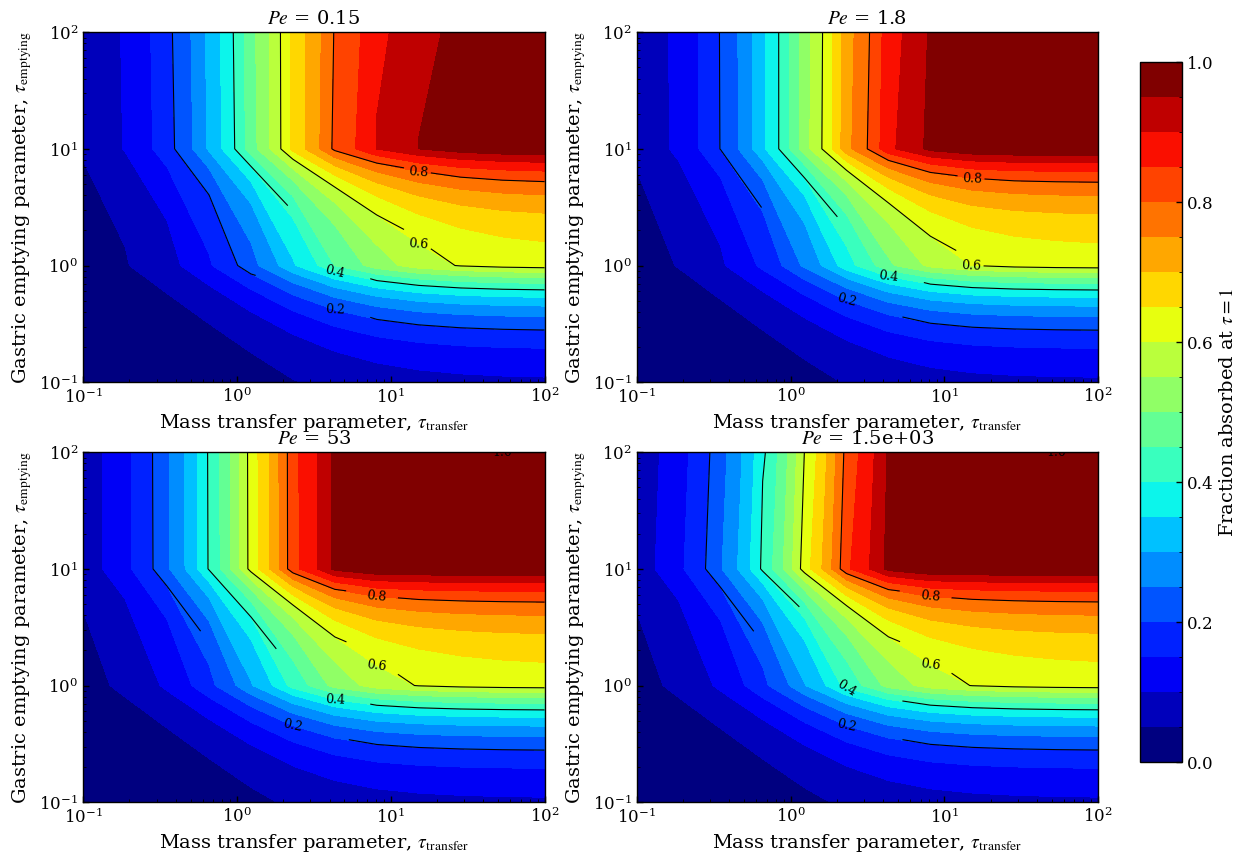

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------
# Choose 4 Peclet values
# -------------------------
# Use 4 log-spaced indices from existing Pe_vals
pe_indices = np.linspace(0, len(Pe_vals)-1, 4, dtype=int)
Pe_panels = Pe_vals[pe_indices]

levels = np.linspace(0.0, 1.0, 21)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cf = None

for ax, pe_idx, Pe_val in zip(axes, pe_indices, Pe_panels):

    # Extract matrix for fixed Pe
    # Shape: (len(tau_emptying), len(tau_transfer))
    Z = F_data[:, :, pe_idx]

    cf = ax.contourf(
        tau_transfer_vals,       # x-axis
        phi_slices,              # y-axis (tau_emptying)
        Z,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="neither"
    )

    cs = ax.contour(
        tau_transfer_vals,
        phi_slices,
        Z,
        levels=[0.2, 0.4, 0.6, 0.8, 0.999999999],
        colors="k",
        linewidths=0.8
    )

    ax.clabel(cs, fmt="%.1f", fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Mass transfer parameter, $\tau_{\mathrm{transfer}}$")
    ax.set_ylabel(r"Gastric emptying parameter, $\tau_{\mathrm{emptying}}$")
    ax.set_title(r"$Pe$ = " + f"{Pe_val:.2g}")

# Shared colorbar
fig.subplots_adjust(right=0.85)

tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(cf, cax=cax, ticks=tick_vals)\
   .set_label(r"Fraction absorbed at $\tau=1$")

plt.show()


In [ ]:
from joblib import Parallel, delayed
from tqdm import tqdm
import matplotlib as mpl

# 2D Parameter Sweep: Computation Only (run once)

# Sweep setup: Pe (x-axis), tau_transfer (y-axis), tau_emptying held at slices
# Use coarser grids for runtime: 12×12 instead of 25×25
Pe_vals = 1.5 * np.logspace(-1, 3, 12)             # 0.15 → 150
tau_transfer_vals = np.logspace(-1, 2, 12)  # 10^-1 → 10^2 (0.1 to 100 like in fig4c)
phi_slices = [0.1, 1, 10, 100]              # Gastric emptying "slices" (τ_emptying)

# Constant: high physiological reaction baseline (not reaction-limited)
Vmax_baseline = 16.0
# Shorter integration window: just beyond τ=1 for interpolation
tau_end = 1.05
# Moderate solver tolerances for parameter sweeps
rtol_sweep = 1e-6
atol_sweep = 1e-9
# Coarser spatial grid for faster runs
nx_sweep = 400

# Reaction timescale from baseline Vmax
tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)

# Allocate storage for full 3D parameter sweep: [phi_index, tau_transfer_index, Pe_index]
F_data = np.zeros((len(phi_slices), len(tau_transfer_vals), len(Pe_vals)))

# Helper to run a single simulation point
def _run_point(phi_idx, tau_idx, pe_idx):
    tau_em = phi_slices[phi_idx]
    tau_tr = tau_transfer_vals[tau_idx]
    Pe_val = Pe_vals[pe_idx]

    res = simulate_model3_conservative(
        tau_tr, tau_em, tauR, KmII, tau_end,
        Pe_override=Pe_val, nx_override=nx_sweep,
        rtol=rtol_sweep, atol=atol_sweep,
    )
    F_val = float(np.clip(
        np.interp(1.0, res["tau"], res["absorbed_fraction"]), 0.0, 1.0
    ))
    return phi_idx, tau_idx, pe_idx, F_val

# Build list of all parameter index triplets
index_triplets = [
    (k, i, j)
    for k in range(len(phi_slices))
    for i in range(len(tau_transfer_vals))
    for j in range(len(Pe_vals))
]

# Parallel sweep over all combinations with progress bar
results = Parallel(n_jobs=-1)(
    delayed(_run_point)(k, i, j) for (k, i, j) in tqdm(
        index_triplets,
        total=len(index_triplets),
        desc="Computing F_data (phi, tau_transfer, Pe)",
    )
)

for k, i, j, F_val in results:
    F_data[k, i, j] = F_val

print("Sensitivity sweep complete. F_data shape:", F_data.shape)

Computing F_data (phi, tau_transfer, Pe): 100%|██████████| 576/576 [06:43<00:00,  1.43it/s]


Sensitivity sweep complete. F_data shape: (4, 12, 12)


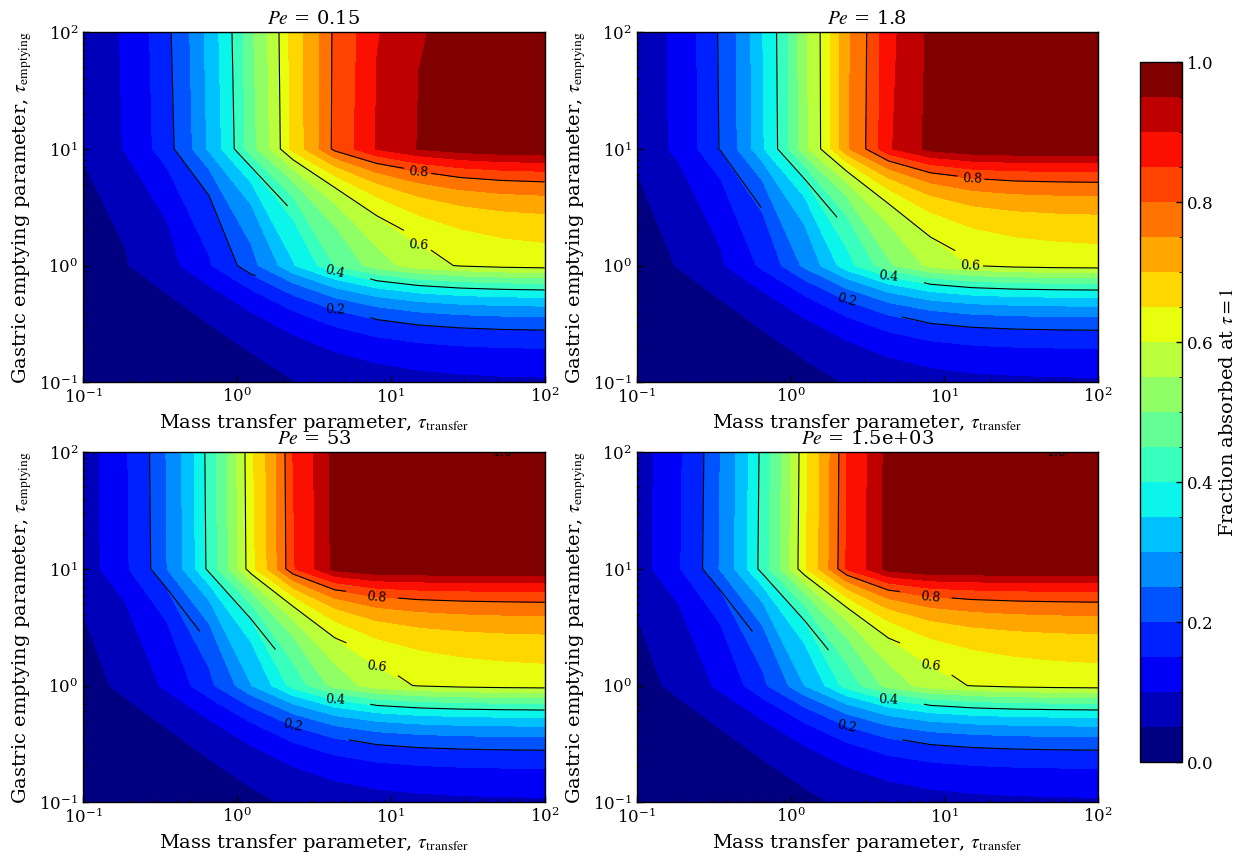

In [ ]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt

# -------------------------
# Choose 4 Peclet values
# -------------------------
# Use 4 log-spaced indices from existing Pe_vals
pe_indices = np.linspace(0, len(Pe_vals)-1, 4, dtype=int)
Pe_panels = Pe_vals[pe_indices]

levels = np.linspace(0.0, 1.0, 21)
cmap = plt.get_cmap("jet")
norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

cf = None

for ax, pe_idx, Pe_val in zip(axes, pe_indices, Pe_panels):

    # Extract matrix for fixed Pe
    # Shape: (len(tau_emptying), len(tau_transfer))
    Z = F_data[:, :, pe_idx]

    cf = ax.contourf(
        tau_transfer_vals,       # x-axis
        phi_slices,              # y-axis (tau_emptying)
        Z,
        levels=levels,
        cmap=cmap,
        norm=norm,
        extend="neither"
    )

    cs = ax.contour(
        tau_transfer_vals,
        phi_slices,
        Z,
        levels=[0.2, 0.4, 0.6, 0.8, 0.999999999],
        colors="k",
        linewidths=0.8
    )

    ax.clabel(cs, fmt="%.1f", fontsize=9)

    ax.set_xscale("log")
    ax.set_yscale("log")

    ax.set_xlabel(r"Mass transfer parameter, $\tau_{\mathrm{transfer}}$")
    ax.set_ylabel(r"Gastric emptying parameter, $\tau_{\mathrm{emptying}}$")
    ax.set_title(r"$Pe$ = " + f"{Pe_val:.2g}")

# Shared colorbar
fig.subplots_adjust(right=0.85)

tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
cax = fig.add_axes([0.88, 0.15, 0.03, 0.7])
fig.colorbar(cf, cax=cax, ticks=tick_vals)\
   .set_label(r"Fraction absorbed at $\tau=1$")

plt.show()


In [ ]:
# import matplotlib as mpl

# # Sweep setup: Pe (x-axis), tau_transfer (y-axis), tau_emptying held at slices
# # Use coarser grids for runtime: 12×12 instead of 25×25
# Pe_vals = 1.5 * np.logspace(-1, 3, 12)             # 0.15 → 150
# tau_transfer_vals = np.logspace(-1, 2, 12)  # 10^-1 → 10^2 (0.1 to 100 like in fig4c)
# phi_slices = [0.1, 1, 10, 100]              # Gastric emptying "slices" (τ_emptying)

# # Constant: high physiological reaction baseline (not reaction-limited)
# Vmax_baseline = 16.0
# # Shorter integration window: just beyond τ=1 for interpolation
# tau_end = 1.05
# # Moderate solver tolerances for parameter sweeps
# rtol_sweep = 1e-6
# atol_sweep = 1e-9
# # Coarser spatial grid for faster runs
# nx_sweep = 400

# tauR = tau_R_from_Vmax(Vmax_baseline, C0_mM)

# fig, axes = plt.subplots(2, 2, figsize=(12, 10))
# axes = axes.flatten()
# levels = np.linspace(0.0, 1.0, 21)
# cmap = plt.get_cmap("jet")
# norm = mpl.colors.BoundaryNorm(levels, ncolors=cmap.N, clip=True)

# for ax, phi in zip(axes, phi_slices):
#     tau_em = phi
#     F_matrix = np.zeros((tau_transfer_vals.size, Pe_vals.size))
#     for i, tau_tr in enumerate(tau_transfer_vals):
#         for j, Pe_val in enumerate(Pe_vals):
#             res = simulate_model3_conservative(
#                 tau_tr, tau_em, tauR, KmII, tau_end,
#                 Pe_override=Pe_val, nx_override=nx_sweep,
#                 rtol=rtol_sweep, atol=atol_sweep
#             )
#             F_matrix[i, j] = float(np.clip(
#                 np.interp(1.0, res["tau"], res["absorbed_fraction"]), 0.0, 1.0
#             ))
#     cf = ax.contourf(Pe_vals, tau_transfer_vals, F_matrix,
#                      levels=levels, cmap=cmap, norm=norm, extend="neither")
#     cs = ax.contour(Pe_vals, tau_transfer_vals, F_matrix,
#                     levels=[0.2, 0.4, 0.6, 0.8, 0.999999999], colors="k", linewidths=0.8)
#     ax.clabel(cs, fmt="%.1f", fontsize=9)
#     ax.set_xscale("log")
#     ax.set_yscale("log")
#     ax.set_xlabel(r"Peclet Number, $Pe$")
#     ax.set_ylabel(r"Mass transfer characteristic time, $\tau_{\mathrm{transfer}}$")
#     ax.set_title(r"$\tau_{\mathrm{emptying}}$ = " + f"{phi}")

# tick_vals = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0]
# cbar = fig.colorbar(cf, ax=axes, ticks=tick_vals)
# cbar.set_label(r"Fraction absorbed at $\tau=1$")
# fig.tight_layout()
# plt.show()

In [ ]:
for Pe_val in [2,20,200,2000]:
    res = simulate_model3_old(tau_tr,tau_em,tauR,KmII,tau_end_3h,Pe_override=Pe_val)
    print(Pe_val, res.get("Pe_used",None), res["mb_err"])

2 2 0.00031774935137351967
20 20 7.660173120083158e-05
200 200 1.6789130086181103e-08
2000 2000 4.899436412131308e-11


## Why the Old Scheme Exhibited Grid-Dependent Mass Drift

### Root Causes of Mass Error in the Original Implementation

The original `simulate_model3_old` implementation exhibited mass errors of order $10^{-4}$ at low Peclet number due to inconsistencies between the discrete transport operator, boundary treatment, and mass accounting.

#### 1. **Non-Conservative Discretization**

The original scheme discretized the transport equation in pointwise derivative form,
$$
\frac{\partial C}{\partial t}
=
-\frac{\partial C}{\partial \xi}
+
\frac{1}{Pe}\frac{\partial^2 C}{\partial \xi^2}
+
R,
$$
using **upwind differencing for advection** and a **separate finite-difference stencil for dispersion**.  
Because the discrete operator is not written in flux-divergence form, the numerical mass flux leaving cell \(i\) is not guaranteed to equal the flux entering cell \(i+1\). As a result, internal fluxes do not telescope in the global sum, and discrete mass conservation is not enforc


In [ ]:
# def simulate_tracer_gaussian(Pe, nx=800, tau_end=0.6, sigma=0.02, xi0=0.05,
#                              Cin_func=None, rtol=1e-8, atol=1e-11, N_times=120):
#     """
#     Conservative advection–dispersion tracer.
#     PDE: ∂C/∂τ = -∂/∂ξ( C - (1/Pe)∂C/∂ξ )
#     BCs: dispersion closed at both ends (Neumann via boundary face treatment),
#          advective inlet prescribed by Cin_func (default 0).
#     """
#     if Cin_func is None:
#         Cin_func = lambda tau: 0.0

#     xi = np.linspace(0.0, 1.0, nx)
#     dxi = xi[1] - xi[0]
#     xi_int = xi[1:]            # interior nodes 1..nx-1
#     n = nx - 1

#     # IC: Gaussian pulse on interior, normalized to unit mass (consistent with state)
#     C0 = np.exp(-((xi_int - xi0)**2) / (2*sigma**2))
#     C0 /= (dxi * np.sum(C0))

#     def rhs(tau, C_int):
#         # full field with inlet value used only for upwind advection at inlet face
#         C = np.empty(nx)
#         C[1:] = C_int
#         Cin = float(Cin_func(tau))∫
#         C[0] = Cin

#         # face fluxes between node i and i+1 for i=0..nx-2
#         J = C[:-1] - (1.0/Pe) * (C[1:] - C[:-1]) / dxi

#         # outlet face flux (Neumann for dispersion => pure advection at ξ=1)
#         J_out = C[-1]

#         dC = np.empty_like(C_int)
#         dC[:-1] = -(J[1:] - J[:-1]) / dxi
#         dC[-1]  = -(J_out - J[-1]) / dxi
#         return dC

#     t_eval = np.linspace(0.0, tau_end, N_times)
#     sol = solve_ivp(rhs, (0.0, tau_end), C0, t_eval=t_eval, method="BDF", rtol=rtol, atol=atol)
#     if not sol.success:
#         raise RuntimeError(sol.message)

#     C_hist = sol.y.T
#     mass = dxi * np.sum(C_hist, axis=1)
#     mass_err = np.abs(mass - 1.0)

#     return {"tau_grid": sol.t, "xi_grid": xi_int, "C_history": C_hist,
#             "mass_error_time": mass_err, "Pe": Pe}
